# Финальный проект. Этап 3 — Анализ данных

**Цель этапа:** выявить закономерности и точки роста бизнеса: динамика во времени, эффективность каналов и кампаний, работа менеджеров, продукты и платежи, география продаж.

**Данные:** очищенные CSV из `data_clean/` (результат этапа 1).

---

## План этапа 3

| Раздел | Что анализируем | Таблица | Пункт ТЗ |
|---|---|---|---|
| **1** | Загрузка данных и подготовка дат | Deals, Calls, Spend | — |
| **2** | Временные ряды: динамика создания сделок (месяц/неделя, конверсия) | Deals | 3.3.1 |
| **3** | Динамика звонков и связь со сделками (звонков на сделку) | Calls + Deals | 3.3.1 |
| **4** | Время жизни сделки: от создания до закрытия | Deals | 3.3.2 |
| **5** | Кампании: объём лидов и конверсия | Deals | 3.4.1 |
| **6** | Источники трафика: качество лидов (доля A+B) | Deals | 3.4.2 |
| **7** | Отдел продаж: сделки, конверсия, выручка по менеджерам | Deals | 3.5.1 |
| **7.1** | Звонки и скорость ответа: влияние на конверсию | Deals + Calls | 3.5.1 |
| **7.2** | Распределение источников по менеджерам | Deals | 3.5.1 |
| **7.3** | Качество входящих лидов по менеджеру | Deals | 3.5.1 |
| **7.4** | Выручка и средний чек по менеджеру | Deals | 3.5.1 |
| **7.5** | SLA: скорость первого ответа vs конверсия | Deals | 3.5.1 |
| **7.6** | Составной рейтинг менеджеров (percentile rank) | Deals | 3.5.1 |
| **8** | Продукты и платежи | Deals | 3.6 |
| **8.1** | Выручка и конверсия по продуктам | Deals | 3.6.2 |
| **8.2** | Типы оплаты (Payment Type) | Deals | 3.6.1 |
| **8.3** | Типы обучения (Education Type): конверсия и средний чек | Deals | 3.6.2 |
| **8.4** | Причины потери сделок (Lost Reason) — бизнес-группировка | Deals | 3.6 |
| **9** | География | Deals | 3.7 |
| **9.1** | Распределение по городам: объём и конверсия | Deals | 3.7.1 |
| **9.2** | Распределение по странам (GeoNames) | Deals | 3.7.1 |
| **9.3** | Уровень немецкого: нормализация и ограничения | Deals | 3.7.2 |
| **10** | Сводные бизнес-выводы и рекомендации | Deals | — |

> **Примечание по пункту 3.7.2.** Поле `Level of Deutsch` заполнялось менеджерами в свободной форме: `B1`, `б1`, `В1` — одно и то же значение. В разделе 9.3 проводим нормализацию (кириллица → латиница, регистр, пробелы/тире), показываем примеры ненормализуемых записей и обосновываем, почему анализ по уровням требует стандартизации поля в CRM.

## 1. Загрузка данных и подготовка дат

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11


In [2]:
DATA_CLEAN = '../data_clean/'
PLOTS = '../data_clean/plots/'

deals = pd.read_csv(DATA_CLEAN + 'deals_clean.csv', low_memory=False,
                    dtype={'Id': str, 'Contact Name': str})
calls = pd.read_csv(DATA_CLEAN + 'calls_clean.csv', low_memory=False,
                    dtype={'Id': str, 'CONTACTID': str})
spend = pd.read_csv(DATA_CLEAN + 'spend_clean.csv', low_memory=False)

print('Загружено:')
print(f'  Deals:  {deals.shape}')
print(f'  Calls:  {calls.shape}')
print(f'  Spend:  {spend.shape}')
print()

# Общая выручка — только сделки с Payment Done И заполненной суммой
_paid = deals[(deals['Stage'] == 'Payment Done') & deals['Initial Amount Paid'].notna()]
print(f'Оплаченных сделок: {len(_paid)} ({len(_paid)/len(deals)*100:.1f}% от всех)')
print(f'Общая выручка (Initial Amount Paid): {_paid["Initial Amount Paid"].sum():,.0f} €')


Загружено:
  Deals:  (21593, 26)
  Calls:  (95874, 9)
  Spend:  (19862, 8)

Оплаченных сделок: 843 (3.9% от всех)
Общая выручка (Initial Amount Paid): 950,351 €


In [3]:
# CSV не хранит типы — восстанавливаем после загрузки
deals['Id']           = deals['Id'].astype(str)
deals['Created Time'] = pd.to_datetime(deals['Created Time'])
deals['Closing Date'] = pd.to_datetime(deals['Closing Date'], errors='coerce')
# 3 строки с 'F' в Quality — не входит в шкалу A–E, пропущено в 01_cleaning.ipynb → исправляем здесь
deals.loc[deals['Quality'] == 'F', 'Quality'] = None

for col in ['Quality', 'Stage', 'Source', 'Product', 'Payment Type', 'Education Type', 'Lost Reason']:
    deals[col] = deals[col].astype('category')

calls['Id']              = calls['Id'].astype(str)
calls['Call Start Time'] = pd.to_datetime(calls['Call Start Time'])
for col in ['Call Type', 'Call Status', 'Outgoing Call Status']:
    calls[col] = calls[col].astype('category')

spend['Date']   = pd.to_datetime(spend['Date'])
spend['Source'] = spend['Source'].astype('category')

In [4]:
# Добавляем удобные временные признаки для группировки
deals['Created Month'] = deals['Created Time'].dt.to_period('M')
deals['Created Week']  = deals['Created Time'].dt.to_period('W')
deals['Created Day']   = deals['Created Time'].dt.date

calls['Call Month'] = calls['Call Start Time'].dt.to_period('M')

print('Новые признаки для группировки (пример по первым строкам):')
display(deals[['Created Time', 'Created Month', 'Created Week', 'Created Day']].head(3))
display(calls[['Call Start Time', 'Call Month']].head(3))

Новые признаки для группировки (пример по первым строкам):


,Created Time,Created Month,Created Week,Created Day
0,2024-06-15 13:50:00,2024-06,2024-06-10/2024-06-16,2024-06-15
1,2024-06-06 14:53:00,2024-06,2024-06-03/2024-06-09,2024-06-06
2,2024-05-31 18:08:00,2024-05,2024-05-27/2024-06-02,2024-05-31


,Call Start Time,Call Month
0,2023-12-15 19:05:00,2023-12
1,2024-05-10 17:34:00,2024-05
2,2024-03-14 19:46:00,2024-03


## 2. Временные ряды: динамика создания сделок

Смотрим, как менялся поток лидов со временем —
это позволяет увидеть сезонность, пики активности и провалы.


In [5]:
# Группируем по месяцам — агрегируем число сделок
monthly_deals = (
    deals.groupby('Created Month', observed=True)
    .size()
    .reset_index(name='Deals Count')
)

# Period → datetime для корректного отображения на графике
monthly_deals['Month'] = monthly_deals['Created Month'].dt.to_timestamp()

print('Сделок по месяцам:')
print(monthly_deals[['Month', 'Deals Count']].to_string(index=False))


Сделок по месяцам:
     Month  Deals Count
2023-07-01          654
2023-08-01         1085
2023-09-01         1079
2023-10-01         1598
2023-11-01         1947
2023-12-01         1811
2024-01-01         2243
2024-02-01         2184
2024-03-01         2252
2024-04-01         3082
2024-05-01         1984
2024-06-01         1674


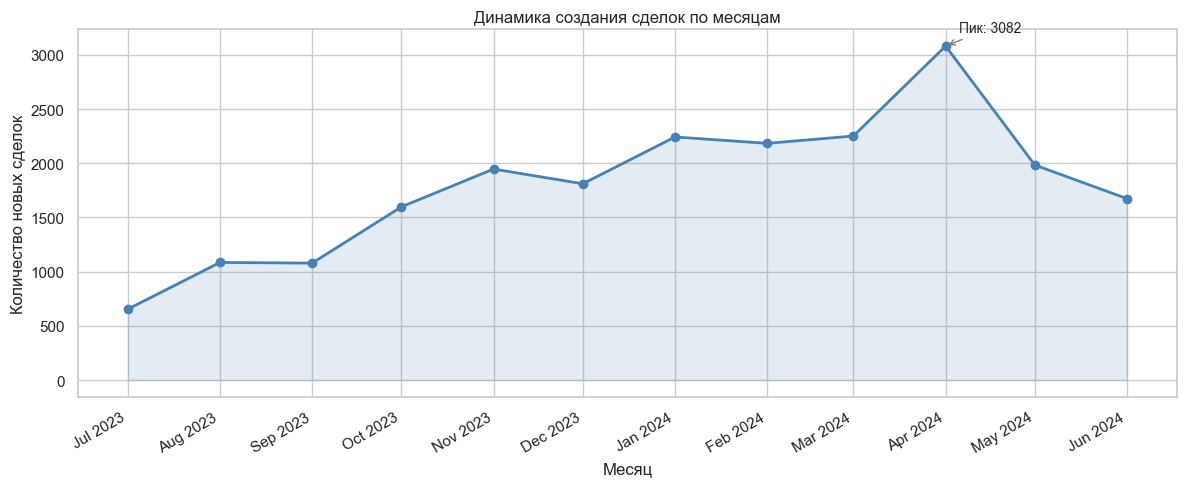

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly_deals['Month'], monthly_deals['Deals Count'],
        marker='o', linewidth=2, color='steelblue', markersize=6)
ax.fill_between(monthly_deals['Month'], monthly_deals['Deals Count'],
                alpha=0.15, color='steelblue')

ax.set_title('Динамика создания сделок по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество новых сделок')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

# Помечаем пик
peak_idx = monthly_deals['Deals Count'].idxmax()
peak_row = monthly_deals.loc[peak_idx]
ax.annotate(f'Пик: {peak_row["Deals Count"]}',
            xy=(peak_row['Month'], peak_row['Deals Count']),
            xytext=(10, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS + 'ts_deals_monthly.png', dpi=100)
plt.show()


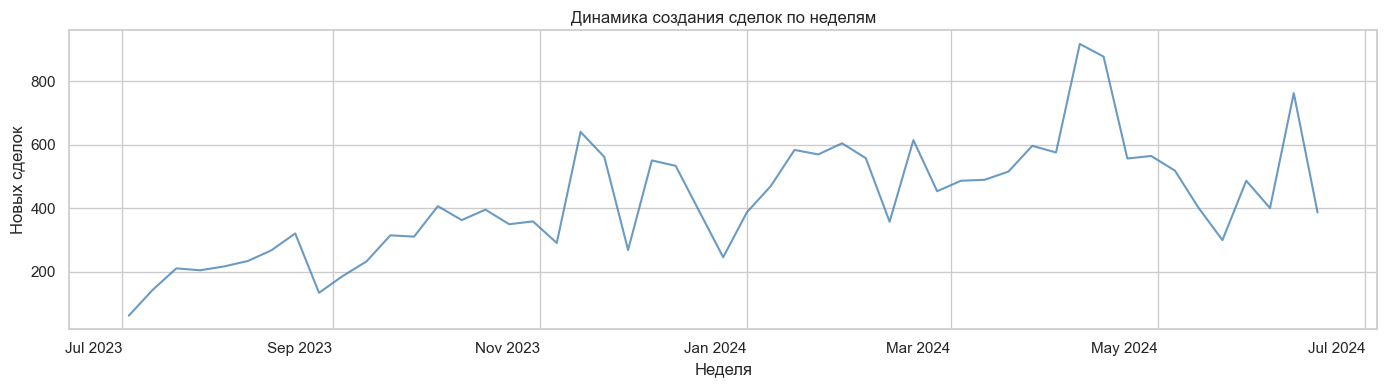

In [7]:
# Недельная динамика — видны краткосрочные колебания
weekly_deals = (
    deals.groupby('Created Week')
    .size()
    .reset_index(name='Deals Count')
)
weekly_deals['Week'] = weekly_deals['Created Week'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(weekly_deals['Week'], weekly_deals['Deals Count'],
        linewidth=1.5, color='steelblue', alpha=0.8)
ax.set_title('Динамика создания сделок по неделям')
ax.set_xlabel('Неделя')
ax.set_ylabel('Новых сделок')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=0, ha='right')

plt.tight_layout()
plt.savefig(PLOTS + 'ts_deals_weekly.png', dpi=100)
plt.show()


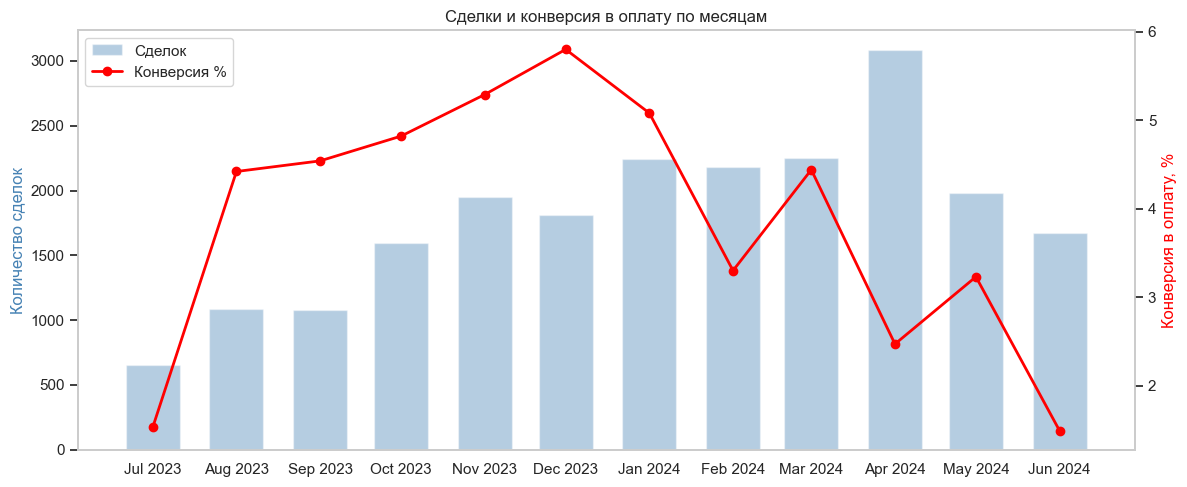

In [8]:
# Конверсия по месяцам — растёт ли качество со временем?
monthly_conv = deals.groupby('Created Month', observed=True).apply(
    lambda x: pd.Series({
        'Deals': len(x),
        'Paid': ((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum(),
        'Conversion %': round(((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum() / len(x) * 100, 2)
    }), include_groups=False
).reset_index()
monthly_conv['Month'] = monthly_conv['Created Month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 5))

# Ось 1: число сделок (столбцы)
ax1.bar(monthly_conv['Month'], monthly_conv['Deals'],
        width=20, color='steelblue', alpha=0.4, label='Сделок')
ax1.set_ylabel('Количество сделок', color='steelblue')
ax1.grid(False)

# Ось 2: конверсия (линия)
ax2 = ax1.twinx()
ax2.plot(monthly_conv['Month'], monthly_conv['Conversion %'],
         color='red', marker='o', linewidth=2, label='Конверсия %')
ax2.set_ylabel('Конверсия в оплату, %', color='red')
ax2.grid(False)

ax1.set_title('Сделки и конверсия в оплату по месяцам')
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(PLOTS + 'ts_deals_conversion_monthly.png', dpi=100)
plt.show()


In [9]:
# Выводим таблицу с лучшими и худшими месяцами по конверсии
print('Конверсия по месяцам (сортировка по убыванию):')
print(monthly_conv[['Month', 'Deals', 'Paid', 'Conversion %']]
      .sort_values('Conversion %', ascending=False)
      .to_string(index=False))


Конверсия по месяцам (сортировка по убыванию):
     Month  Deals  Paid  Conversion %
2023-12-01 1811.0 105.0          5.80
2023-11-01 1947.0 103.0          5.29
2024-01-01 2243.0 114.0          5.08
2023-10-01 1598.0  77.0          4.82
2023-09-01 1079.0  49.0          4.54
2024-03-01 2252.0 100.0          4.44
2023-08-01 1085.0  48.0          4.42
2024-02-01 2184.0  72.0          3.30
2024-05-01 1984.0  64.0          3.23
2024-04-01 3082.0  76.0          2.47
2023-07-01  654.0  10.0          1.53
2024-06-01 1674.0  25.0          1.49


**Вывод (раздел 2):** Пик по числу лидов — апрель 2024 (3 082 сделки). Лучшая конверсия в оплату — декабрь 2023 (5,80%), худшая — июнь 2024 (1,49%). Пики по объёму и качеству не совпадают: апрельский рост лидов сопровождался резким падением конверсии, что указывает на снижение качества трафика при масштабировании кампаний.

## 3. Динамика звонков и её связь со сделками

In [10]:
# Звонки по месяцам
monthly_calls = (
    calls.groupby('Call Month', observed=True)
    .size()
    .reset_index(name='Calls Count')
)
monthly_calls['Month'] = monthly_calls['Call Month'].dt.to_timestamp()

print('Звонки по месяцам:')
print(monthly_calls[['Month', 'Calls Count']].to_string(index=False))


Звонки по месяцам:
     Month  Calls Count
2023-06-01            7
2023-07-01         1935
2023-08-01         4251
2023-09-01         5156
2023-10-01         7102
2023-11-01         7170
2023-12-01         7099
2024-01-01         9804
2024-02-01         9599
2024-03-01        10081
2024-04-01        13328
2024-05-01        11847
2024-06-01         8495


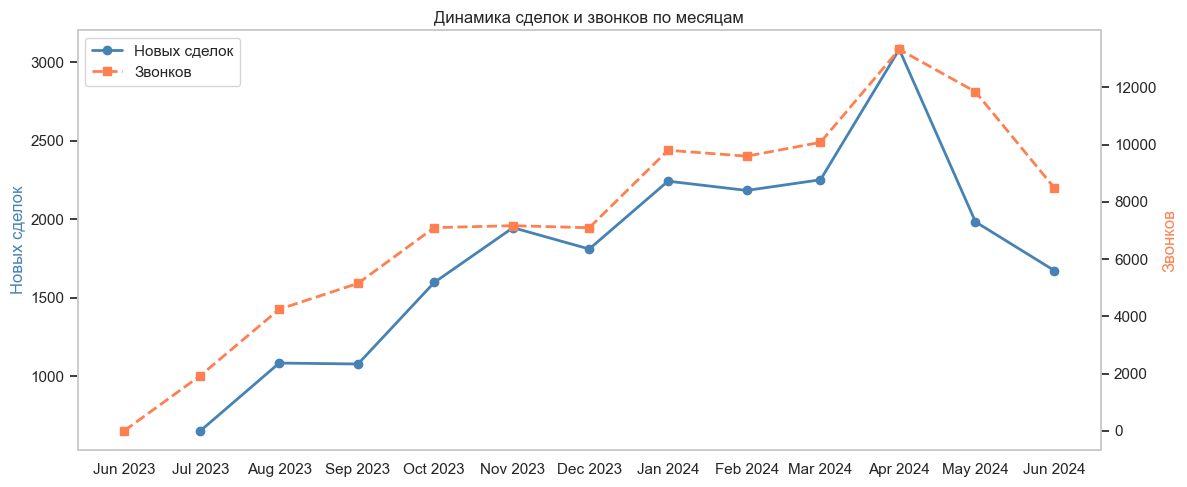

In [11]:
# Сравниваем динамику сделок и звонков на одном графике
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly_deals['Month'], monthly_deals['Deals Count'],
         marker='o', linewidth=2, color='steelblue', label='Новых сделок')
ax1.set_ylabel('Новых сделок', color='steelblue')
ax1.grid(False)

ax2 = ax1.twinx()
ax2.plot(monthly_calls['Month'], monthly_calls['Calls Count'],
         marker='s', linewidth=2, color='coral', linestyle='--', label='Звонков')
ax2.set_ylabel('Звонков', color='coral')
ax2.grid(False)

ax1.set_title('Динамика сделок и звонков по месяцам')
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(PLOTS + 'ts_deals_vs_calls.png', dpi=100)
plt.show()


In [12]:
# Среднее число звонков на сделку по месяцам
merged = pd.merge(
    monthly_deals[['Month', 'Deals Count']],
    monthly_calls[['Month', 'Calls Count']],
    on='Month', how='inner'
)
merged['Calls per Deal'] = (merged['Calls Count'] / merged['Deals Count']).round(1)
print('Звонков на одну сделку по месяцам:')
print(merged[['Month', 'Deals Count', 'Calls Count', 'Calls per Deal']].to_string(index=False))


Звонков на одну сделку по месяцам:
     Month  Deals Count  Calls Count  Calls per Deal
2023-07-01          654         1935             3.0
2023-08-01         1085         4251             3.9
2023-09-01         1079         5156             4.8
2023-10-01         1598         7102             4.4
2023-11-01         1947         7170             3.7
2023-12-01         1811         7099             3.9
2024-01-01         2243         9804             4.4
2024-02-01         2184         9599             4.4
2024-03-01         2252        10081             4.5
2024-04-01         3082        13328             4.3
2024-05-01         1984        11847             6.0
2024-06-01         1674         8495             5.1


**Вывод (раздел 3):** Динамика звонков повторяет динамику сделок с небольшим отставанием — менеджеры обрабатывают входящий поток. Среднее число звонков на сделку варьируется от 3,0 (июль 2023) до 6,0 (май 2024). Рост нагрузки в мае 2024 — тревожный сигнал: при меньшем числе новых сделок звонков потребовалось значительно больше, что снижает эффективность отдела продаж.

## 4. Время жизни сделки: от создания до закрытия

Сделки делятся на три группы: **активные** (ещё в воронке), **успешные** (Payment Done) и **потерянные** (Lost).

Для завершённых сделок вычисляем время жизни: сколько дней прошло от создания до закрытия — и сравниваем успешные vs потерянные.

**Определения статусов сделок (по правилам CRM):**

- **Активные (в воронке)** — Stage не является `Payment Done` или `Lost`; сделка ещё обрабатывается менеджером (например, `New Lead`, `Need To Call`, `Waiting For Payment` и др.).
- **Успешные (Payment Done)** — менеджер вручную выставил статус `Payment Done`, означает что факт оплаты зафиксирован в CRM.
- **Потерянные (Lost)** — менеджер закрыл сделку как проигранную.

In [13]:
n_total       = len(deals)
n_active      = (~deals['Stage'].isin(['Payment Done', 'Lost'])).sum()

pd_all        = deals[deals['Stage'] == 'Payment Done']
pd_no_amt     = pd_all['Initial Amount Paid'].isna().sum()
pd_date_err   = (pd_all['closing_date_error'] == True).sum()
pd_no_date    = pd_all['Closing Date'].isna().sum()
pd_in_time    = len(pd_all) - pd_date_err - pd_no_date

lost_all      = deals[deals['Stage'] == 'Lost']
lost_date_err = (lost_all['closing_date_error'] == True).sum()
lost_no_date  = lost_all['Closing Date'].isna().sum()
lost_in_time  = len(lost_all) - lost_date_err - lost_no_date

print(f'Всего сделок: {n_total}')
print(f'  Активные (в воронке):           {n_active:>6}  ({n_active/n_total*100:.1f}%)')
print(f'  Успешные (Payment Done):         {len(pd_all):>6}  ({len(pd_all)/n_total*100:.1f}%)')
print(f'    — нет суммы оплаты:            {pd_no_amt:>6}  (не входят в unit-экономику)')
print(f'    — дата закрытия < создания:    {pd_date_err:>6}  (исключены из анализа времени)')
print(f'    — нет даты закрытия:           {pd_no_date:>6}  (исключены из анализа времени)')
print(f'    → в анализе времени:           {pd_in_time:>6}')
print(f'  Потерянные (Lost):               {len(lost_all):>6}  ({len(lost_all)/n_total*100:.1f}%)')
print(f'    — дата закрытия < создания:    {lost_date_err:>6}  (исключены из анализа времени)')
print(f'    — нет даты закрытия:           {lost_no_date:>6}  (исключены из анализа времени)')
print(f'    → в анализе времени:           {lost_in_time:>6}')
print(f'  Сверка: {n_active} + {len(pd_all)} + {len(lost_all)} = {n_active+len(pd_all)+len(lost_all)}')
print()

# Время жизни — только сделки с корректной датой закрытия
closed = deals[
    deals['Closing Date'].notna() & (deals['closing_date_error'] == False)
].copy()
closed['Days to Close'] = (
    closed['Closing Date'] - closed['Created Time']
).dt.days.clip(lower=0)

paid_tc = closed[closed['Stage'] == 'Payment Done']['Days to Close']
lost_tc = closed[closed['Stage'] == 'Lost']['Days to Close']

print('Время от создания до закрытия (дней):')
print()
for label, s in [('Успешные (Payment Done)', paid_tc), ('Потерянные (Lost)', lost_tc)]:
    d = s.describe()
    print(f'--- {label}: {len(s)} сделок ---')
    print(f'  Среднее:  {d["mean"]:.1f} дн.   Медиана: {d["50%"]:.1f} дн.')
    print(f'  Мин: {d["min"]:.0f} дн.   Макс: {d["max"]:.0f} дн.')
    print(f'  25%-75%:  {d["25%"]:.0f} – {d["75%"]:.0f} дн.')
    print()


Всего сделок: 21593
  Активные (в воронке):             4992  (23.1%)
  Успешные (Payment Done):            858  (4.0%)
    — нет суммы оплаты:                15  (не входят в unit-экономику)
    — дата закрытия < создания:         4  (исключены из анализа времени)
    — нет даты закрытия:              337  (исключены из анализа времени)
    → в анализе времени:              517
  Потерянные (Lost):                15743  (72.9%)
    — дата закрытия < создания:        40  (исключены из анализа времени)
    — нет даты закрытия:             1885  (исключены из анализа времени)
    → в анализе времени:            13818
  Сверка: 4992 + 858 + 15743 = 21593

Время от создания до закрытия (дней):

--- Успешные (Payment Done): 517 сделок ---
  Среднее:  32.6 дн.   Медиана: 16.0 дн.
  Мин: 0 дн.   Макс: 304 дн.
  25%-75%:  6 – 42 дн.

--- Потерянные (Lost): 13818 сделок ---
  Среднее:  13.4 дн.   Медиана: 2.0 дн.
  Мин: 0 дн.   Макс: 334 дн.
  25%-75%:  0 – 10 дн.



In [14]:
# Вычисляем серии дней для Payment Done и Lost
paid_days = closed.loc[closed['Stage'] == 'Payment Done', 'Days to Close'].dropna()
lost_days = closed.loc[closed['Stage'] == 'Lost', 'Days to Close'].dropna()

# Прежде чем обрезать график — смотрим, сколько % сделок укладывается в разные горизонты
thresholds = [30, 60, 90, 120, 180]
print(f"{'Порог':>8} | {'Payment Done (%)':>16} | {'Lost (%)':>9}")
print('-' * 42)
for t in thresholds:
    p_pct = (paid_days <= t).mean() * 100
    l_pct = (lost_days <= t).mean() * 100
    print(f"{t:>5} дн. | {p_pct:>15.1f}% | {l_pct:>8.1f}%")


   Порог | Payment Done (%) |  Lost (%)
------------------------------------------
   30 дн. |            66.3% |     87.8%
   60 дн. |            83.6% |     93.4%
   90 дн. |            90.5% |     96.3%
  120 дн. |            94.6% |     97.9%
  180 дн. |            98.3% |     99.3%


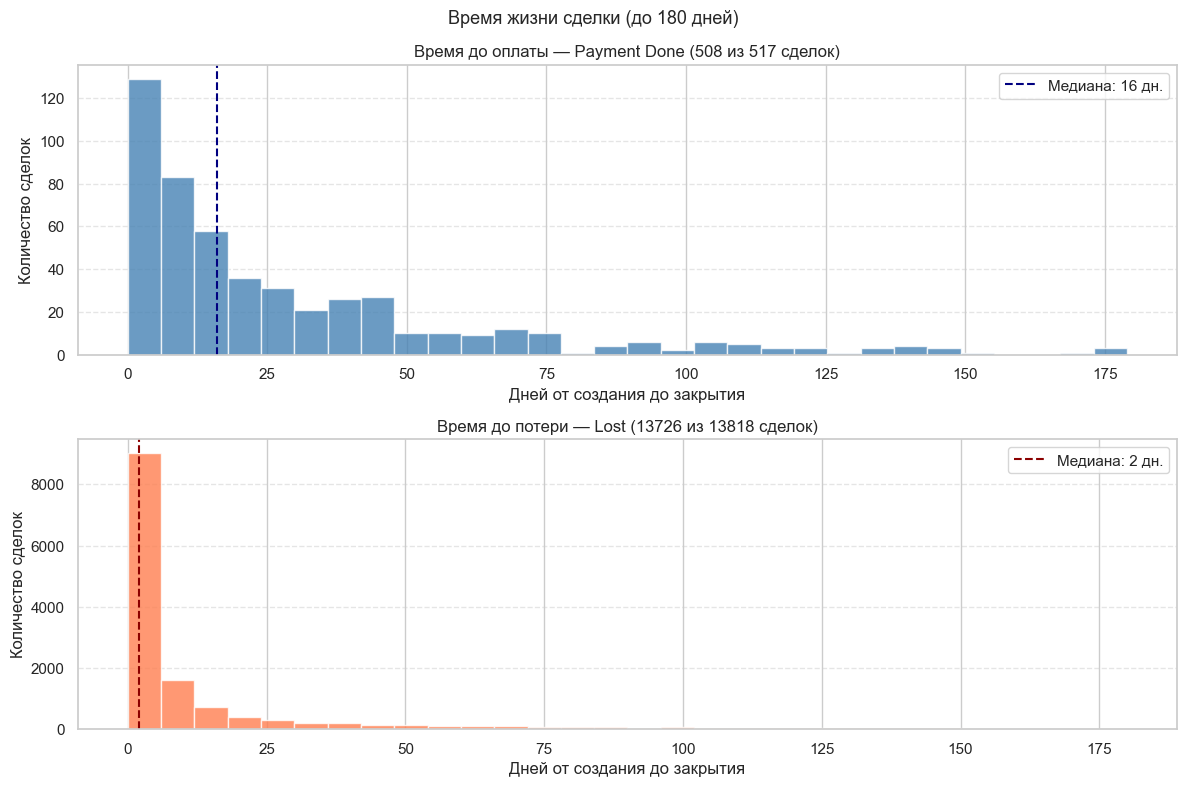

In [15]:
paid_trimmed = paid_days[paid_days <= 180]
lost_trimmed = lost_days[lost_days <= 180]

# sharex=False — у каждого subplot своя независимая ось X с подписями
fig, (ax_paid, ax_lost) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# --- Успешные ---
ax_paid.hist(paid_trimmed, bins=30, color='steelblue', alpha=0.8)
ax_paid.axvline(paid_trimmed.median(), color='navy', linestyle='--',
                label=f'Медиана: {paid_trimmed.median():.0f} дн.')
ax_paid.set_title('Время до оплаты — Payment Done (' + str(len(paid_trimmed)) + ' из ' + str(len(paid_days)) + ' сделок)')
ax_paid.set_ylabel('Количество сделок')
ax_paid.set_xlabel('Дней от создания до закрытия')
ax_paid.legend()
ax_paid.grid(axis='y', linestyle='--', alpha=0.5)

# --- Потерянные ---
ax_lost.hist(lost_trimmed, bins=30, color='coral', alpha=0.8)
ax_lost.axvline(lost_trimmed.median(), color='darkred', linestyle='--',
                label=f'Медиана: {lost_trimmed.median():.0f} дн.')
ax_lost.set_title('Время до потери — Lost (' + str(len(lost_trimmed)) + ' из ' + str(len(lost_days)) + ' сделок)')
ax_lost.set_ylabel('Количество сделок')
ax_lost.set_xlabel('Дней от создания до закрытия')
ax_lost.legend()
ax_lost.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Время жизни сделки (до 180 дней)', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS + 'deal_lifecycle.png', dpi=100, bbox_inches='tight')
plt.show()


In [16]:
print(f'Медиана дней до оплаты (до 180 дней): {paid_trimmed.median():.0f}')
print(f'Медиана дней до потери (до 180 дней):  {lost_trimmed.median():.0f}')


Медиана дней до оплаты (до 180 дней): 16
Медиана дней до потери (до 180 дней):  2


**Вывод (раздел 4):**

Согласно таблице выше (517 успешных и 13 818 потерянных сделок с корректной датой закрытия):

- **Медиана до оплаты — 16 дн.**, среднее — 32.6 дн. Разброс широкий: межквартильный диапазон 6–42 дня. Часть клиентов принимает решение быстро, часть — долго думает (максимум 304 дня).
- **Медиана до потери — 2 дн.**, среднее — 13.4 дн., межквартильный диапазон 0–10 дней. Потерянные сделки закрываются значительно быстрее успешных: большинство "умирает" в первые дни после создания.
- Разница медиан в 8 раз (16 vs 2 дня) говорит о том, что сделки, которые живут дольше недели, имеют принципиально иной характер — клиент ещё думает, а не просто не отвечает.

Дополнительно: 337 Payment Done (39.3%) не имеют даты закрытия в CRM и в анализ времени не вошли (аномалия зафиксирована в разделе 2.1.3.12 этапа 2).

## 5. Анализ маркетинговых кампаний

Оцениваем эффективность кампаний: сколько лидов привлекают
и какой процент из них конвертируется в оплату.


In [17]:
# Оставляем только сделки с заполненной кампанией
with_campaign = deals[deals['Campaign'].notna()].copy()
print(f'Сделок с кампанией: {len(with_campaign)} из {len(deals)}')


Сделок с кампанией: 16067 из 21593


In [18]:
# Сколько всего уникальных кампаний?
total_campaigns = with_campaign['Campaign'].nunique()
print(f'Всего уникальных кампаний: {total_campaigns}')
print(f'Показываем топ-20 по количеству лидов')

Всего уникальных кампаний: 154
Показываем топ-20 по количеству лидов


In [19]:
# Агрегируем по кампаниям
campaign_stats = (
    with_campaign.groupby('Campaign', observed=True)
    .apply(lambda x: pd.Series({
        'Лидов': len(x),
        'Оплат': ((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum(),
        'Конверсия %': round(((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum() / len(x) * 100, 2)
    }), include_groups=False)
    .reset_index()
    .sort_values('Лидов', ascending=False)
)

# Сколько уникальных кампаний? Берём топ-20 по объёму — это ~80% всего трафика
n_campaigns = len(campaign_stats)
top20_share = campaign_stats.head(20)['Лидов'].sum() / campaign_stats['Лидов'].sum() * 100
print(f'Всего уникальных кампаний: {n_campaigns}')
print(f'Топ-20 охватывают {top20_share:.1f}% всех лидов с кампанией')
print()
print('Топ-20 кампаний по числу лидов:')
print(campaign_stats.head(20).to_string(index=False))


Всего уникальных кампаний: 154
Топ-20 охватывают 80.4% всех лидов с кампанией

Топ-20 кампаний по числу лидов:
                         Campaign  Лидов  Оплат  Конверсия %
performancemax_digitalmarkt_ru_DE 2653.0  109.0         4.11
                youtube_shorts_DE 1635.0   53.0         3.24
                12.07.2023wide_DE 1575.0   48.0         3.05
                  02.07.23wide_DE  975.0   52.0         5.33
         04.07.23recentlymoved_DE  750.0   30.0         4.00
                    03.07.23women  612.0   30.0         4.90
                           Dis_DE  581.0   29.0         4.99
                   07.07.23LAL_DE  542.0   28.0         5.17
        12.09.23interests_Uxui_DE  531.0   26.0         4.90
           24.09.23retargeting_DE  479.0   17.0         3.55
                      webinar1604  343.0    3.0         0.87
                          work_DE  317.0    9.0         2.84
                      webinar1906  290.0    0.0         0.00
          08.04.24wide_webinar_DE  

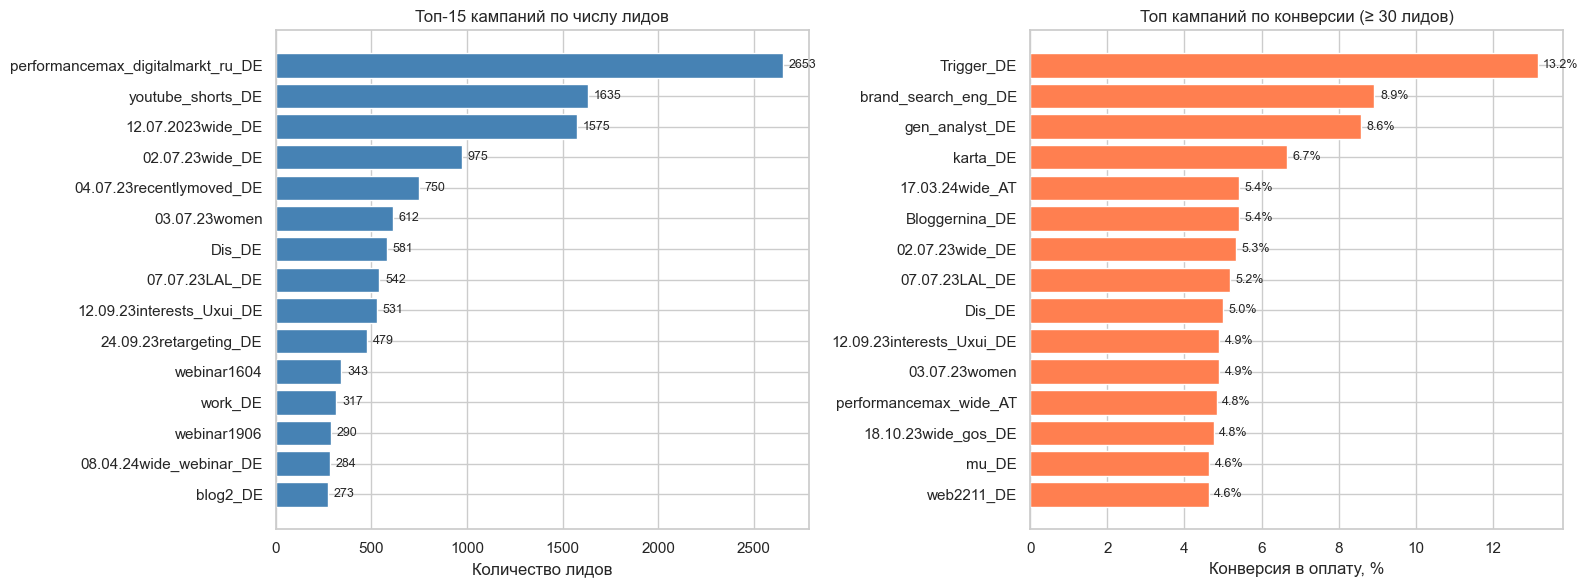

In [20]:
# Топ-15 кампаний по числу лидов — визуализация
top15_campaigns = campaign_stats.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый: лиды по кампаниям
bars = axes[0].barh(top15_campaigns['Campaign'][::-1],
                    top15_campaigns['Лидов'][::-1], color='steelblue')
axes[0].set_title('Топ-15 кампаний по числу лидов')
axes[0].set_xlabel('Количество лидов')
axes[0].bar_label(bars, fmt='%d', padding=4, fontsize=9)

# Правый: конверсия (только кампании с ≥ 30 лидами)
conv_campaigns = campaign_stats[campaign_stats['Лидов'] >= 30].sort_values(
    'Конверсия %', ascending=False).head(15)

bars2 = axes[1].barh(conv_campaigns['Campaign'][::-1],
                     conv_campaigns['Конверсия %'][::-1], color='coral')
axes[1].set_title('Топ кампаний по конверсии (≥ 30 лидов)')
axes[1].set_xlabel('Конверсия в оплату, %')
axes[1].bar_label(bars2, fmt='%.1f%%', padding=4, fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS + 'campaign_analysis.png', dpi=100)
plt.show()


In [21]:
# Обоснование порога: по ЦПТ при n >= 30 выборочное распределение
# пропорции приближается к нормальному — граница из курса между
# параметрическими и непараметрическими тестами.
all_leads = campaign_stats['Лидов'].sum()
n_total_camp = len(campaign_stats)
thresholds = [10, 20, 30, 50, 100]

print(f'Всего кампаний: {n_total_camp},  всего лидов по ним: {all_leads}')
print()
print(f'{"Порог":>8} | {"Кампаний":>9} | {"Отсечено":>9} | {"Лидов в анализе":>16} | {"Лидов потеряно":>15}')
print('-' * 66)
for t in thresholds:
    sub  = campaign_stats[campaign_stats['Лидов'] >= t]
    excl = campaign_stats[campaign_stats['Лидов'] < t]
    leads_in   = sub['Лидов'].sum()
    leads_lost = excl['Лидов'].sum()
    marker = '  <-- берём (ЦПТ)' if t == 30 else ''
    print(f'{t:>5} лид. | {len(sub):>5} кам. | {len(excl):>5} кам. | '
          f'{leads_in:>7} ({leads_in/all_leads*100:.1f}%) | '
          f'{leads_lost:>6} ({leads_lost/all_leads*100:.1f}%){marker}')


Всего кампаний: 154,  всего лидов по ним: 16067.0

   Порог |  Кампаний |  Отсечено |  Лидов в анализе |  Лидов потеряно
------------------------------------------------------------------
   10 лид. |    88 кам. |    66 кам. | 15803.0 (98.4%) |  264.0 (1.6%)
   20 лид. |    64 кам. |    90 кам. | 15485.0 (96.4%) |  582.0 (3.6%)
   30 лид. |    52 кам. |   102 кам. | 15191.0 (94.5%) |  876.0 (5.5%)  <-- берём (ЦПТ)
   50 лид. |    36 кам. |   118 кам. | 14583.0 (90.8%) | 1484.0 (9.2%)
  100 лид. |    30 кам. |   124 кам. | 14169.0 (88.2%) | 1898.0 (11.8%)


In [22]:
# Лучшие кампании по конверсии (минимум 30 лидов)
top_conv = campaign_stats[campaign_stats['Лидов'] >= 30].sort_values(
    'Конверсия %', ascending=False).head(10)
print('Лучшие кампании по конверсии (≥ 30 лидов):')
print(top_conv.to_string(index=False))


Лучшие кампании по конверсии (≥ 30 лидов):
                 Campaign  Лидов  Оплат  Конверсия %
               Trigger_DE   38.0    5.0        13.16
      brand_search_eng_DE  168.0   15.0         8.93
           gen_analyst_DE   35.0    3.0         8.57
                 karta_DE   30.0    2.0         6.67
          17.03.24wide_AT   37.0    2.0         5.41
           Bloggernina_DE   37.0    2.0         5.41
          02.07.23wide_DE  975.0   52.0         5.33
           07.07.23LAL_DE  542.0   28.0         5.17
                   Dis_DE  581.0   29.0         4.99
12.09.23interests_Uxui_DE  531.0   26.0         4.90


**Вывод (раздел 5):** Всего 154 уникальные кампании. Крупнейшая по объёму — `performancemax_digitalmarkt_ru_DE` (2 653 лида, конверсия 4,22%). Среди кампаний с ≥ 30 лидами (порог ЦПТ) лучшую конверсию показывают: `Trigger_DE` (13,16%, 38 лидов) и `brand_search_eng_DE` (8,93%, 168 лидов). Оба — аудитории с высоким намерением (триггерный ретаргетинг и брендовый поиск). Кампании широкого охвата (`02.07.23wide_DE` — 975 лидов) дают конверсию 5,33% — больший объём, но ниже качество. Закономерность: чем «теплее» трафик, тем выше конверсия.

## 6. Источники трафика: качество лидов (оценка менеджеров)

В этом разделе анализируем **качество лидов** — как менеджеры оценивают входящий трафик по шкале A/B/C/D/E.

> **Важно:** «качественный лид» (оценка A/B) ≠ «лид, который заплатил». Конверсия в оплату по источникам уже рассчитана в `02_descriptive.ipynb` (раздел 2.1.3, Webinar — 6,86%, лучший). Здесь смотрим другое: какой процент лидов из каждого источника получил высокую оценку от менеджера.

Сравнение двух метрик в конце раздела покажет, совпадает ли оценка качества с реальной конверсией.

In [23]:
# Разделяем лиды на «качественные» и «нецелевые»
quality_map = {
    'A - High': 'Качественные (A+B)',
    'B - Medium': 'Качественные (A+B)',
    'C - Low': 'Средние (C)',
    'D - Non Target': 'Нецелевые (D+E)',
    'E - Non Qualified': 'Нецелевые (D+E)'
}
deals['Quality Group'] = deals['Quality'].map(quality_map)

# Доля по группам качества для каждого источника
source_quality = (
    deals[deals['Quality'].notna() & deals['Source'].notna()]
    .groupby(['Source', 'Quality Group'], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Добавляем % качественных лидов
if 'Качественные (A+B)' in source_quality.columns:
    source_quality['% качественных'] = (
        source_quality['Качественные (A+B)'] /
        source_quality.sum(axis=1) * 100
    ).round(1)

source_quality['Всего'] = source_quality.sum(axis=1)
source_quality = source_quality.sort_values('Всего', ascending=False)
print(source_quality.to_string())


Quality Group   Качественные (A+B)  Нецелевые (D+E)  Средние (C)  % качественных   Всего
Source                                                                                  
Facebook Ads                   584             2998          896            13.0  4491.0
Google Ads                     405             3104          692             9.6  4210.6
Organic                        276             1829          318            11.4  2434.4
Tiktok Ads                     121             1325          354             6.7  1806.7
Youtube Ads                    129             1213          301             7.9  1650.9
SMM                            165             1041          344            10.6  1560.6
Telegram posts                 108              699          186            10.9  1003.9
Bloggers                       105              685          200            10.6  1000.6
CRM                             40              553           96             5.8   694.8
Webinar              

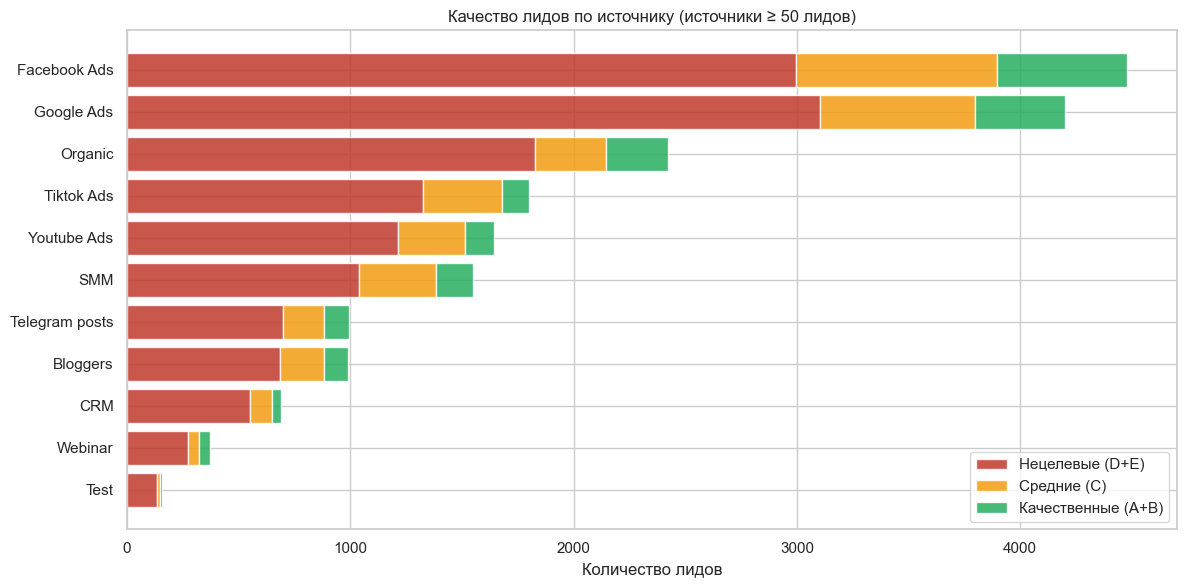

In [24]:
# Визуализация: стекированный барчарт по источникам
sq_plot = source_quality.drop(columns=['Всего', '% качественных'],
                               errors='ignore')
sq_plot = sq_plot[sq_plot.sum(axis=1) >= 50]  # только крупные источники
sq_plot = sq_plot.iloc[::-1]  # barh идёт снизу вверх -> переворачиваем, чтобы крупный был сверху

colors_stack = {'Качественные (A+B)': '#27ae60',
                'Средние (C)': '#f39c12',
                'Нецелевые (D+E)': '#c0392b'}

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(sq_plot))

for col in ['Нецелевые (D+E)', 'Средние (C)', 'Качественные (A+B)']:
    if col in sq_plot.columns:
        values = sq_plot[col].values
        ax.barh(sq_plot.index, values, left=bottom,
                color=colors_stack.get(col, 'gray'), label=col, alpha=0.85)
        bottom += values

ax.set_title('Качество лидов по источнику (источники ≥ 50 лидов)')
ax.set_xlabel('Количество лидов')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(PLOTS + 'source_quality_breakdown.png', dpi=100)
plt.show()


In [25]:
# Рейтинг источников по % качественных лидов
if '% качественных' in source_quality.columns:
    quality_rank = (source_quality[source_quality['Всего'] >= 50]
                    ['% качественных']
                    .sort_values(ascending=False))
    print('% качественных лидов (A+B) по источнику (≥ 50 лидов):')
    print(quality_rank.to_string())


% качественных лидов (A+B) по источнику (≥ 50 лидов):
Source
Partnership       16.2
Facebook Ads      13.0
Webinar           12.9
Organic           11.4
Telegram posts    10.9
SMM               10.6
Bloggers          10.6
Google Ads         9.6
Youtube Ads        7.9
Tiktok Ads         6.7
CRM                5.8
Test               5.7


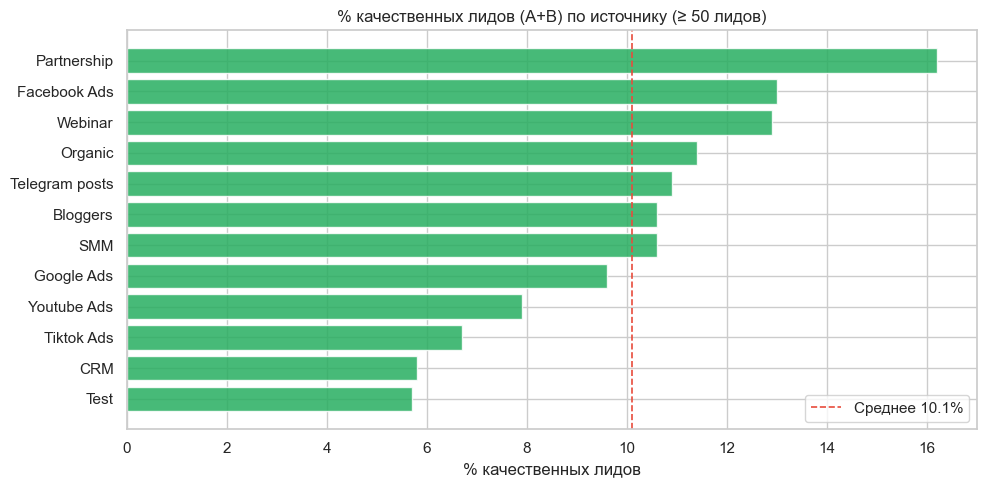

In [26]:
# График: % качественных лидов (A+B) по источнику (≥ 50 лидов)
if '% качественных' in source_quality.columns:
    qr_plot = (source_quality[source_quality['Всего'] >= 50]['% качественных']
               .sort_values(ascending=True))  

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(qr_plot.index, qr_plot.values, color='#27ae60', alpha=0.85)
    ax.axvline(qr_plot.mean(), color='#e74c3c', linestyle='--',
               linewidth=1.2, label=f'Среднее {qr_plot.mean():.1f}%')
    ax.set_title('% качественных лидов (A+B) по источнику (≥ 50 лидов)')
    ax.set_xlabel('% качественных лидов')
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOTS + 'source_quality_pct.png', dpi=100)
    plt.show()

**Вывод (раздел 6):**

По **доле качественных лидов (A+B)** лидирует Partnership (16,2%), затем Facebook Ads (13,0%) и Webinar (12,9%).

Однако **оценка качества менеджером и реальная конверсия в оплату не совпадают** — и это ключевой инсайт:

| Источник | % качественных (A+B) | Конверсия в оплату |
|---|---|---|
| Webinar | 12,9% | **6,86%** — лучший |
| Partnership | **16,2%** — лучший | 1,97% — худший |
| CRM | 5,8% — худший | 1,45% |

Partnership получает высокие оценки от менеджеров, но крайне редко доходит до оплаты (203 лида, 4 оплаты). Webinar даёт умеренную долю качественных лидов, но конвертирует лучше всех — скорее всего, за счёт высокой готовности аудитории к покупке.

**Вывод для бюджета:** ориентироваться только на оценку качества менеджерами недостаточно — нужно смотреть на фактическую конверсию в оплату. По этому критерию Webinar, Organic и SMM — приоритетные каналы.

## 7. Анализ отдела продаж (менеджеры)

Оцениваем каждого менеджера по трём критериям:
количество сделок, конверсия в оплату и суммарная выручка.


In [27]:
# Убираем строки без менеджера
with_owner = deals[deals['Deal Owner Name'].notna()].copy()

# Агрегируем по менеджерам
manager_stats = (
    with_owner.groupby('Deal Owner Name', observed=True)
    .apply(lambda x: pd.Series({
        'Сделок': len(x),
        'Оплат': ((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum(),
        'Конверсия %': round(((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum() / len(x) * 100, 2),
        'Выручка': x.loc[
            (x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna(),
            'Initial Amount Paid'
        ].sum()
    }), include_groups=False)
    .reset_index()
    .sort_values('Конверсия %', ascending=False)
    .set_index('Deal Owner Name')  # имя менеджера — индекс (нужен для isin в разделах 7.2–7.5)
)
manager_stats['Deal Owner Name'] = manager_stats.index  # дублируем как колонку для графиков

# Вывод: имя менеджера — первая колонка
display_cols = ['Deal Owner Name', 'Сделок', 'Оплат', 'Конверсия %', 'Выручка']
print('Статистика менеджеров (сортировка по конверсии):')
display(manager_stats[display_cols])
print()
print('Общая сумма выручки по менеджерам: {:,.0f} €'.format(manager_stats['Выручка'].sum()))
print('Общая сумма выручки : {:,.0f} €'.format(deals[deals['Stage'] == 'Payment Done']['Initial Amount Paid'].sum()))


Статистика менеджеров (сортировка по конверсии):


,Deal Owner Name,Сделок,Оплат,Конверсия %,Выручка
Deal Owner Name,,,,,
Oliver Taylor,Oliver Taylor,163.0,50.0,30.67,50250.0
Ulysses Adams,Ulysses Adams,2165.0,141.0,6.51,126100.0
John Doe,John Doe,20.0,1.0,5.00,0.0
Paula Underwood,Paula Underwood,1862.0,93.0,4.99,100650.0
Charlie Davis,Charlie Davis,2963.0,148.0,4.99,140750.0
Kevin Parker,Kevin Parker,574.0,26.0,4.53,23450.0
Julia Nelson,Julia Nelson,2241.0,93.0,4.15,84551.0
Eva Kent,Eva Kent,459.0,18.0,3.92,20000.0
Victor Barnes,Victor Barnes,1232.0,44.0,3.57,46600.0



Общая сумма выручки по менеджерам: 950,351 €
Общая сумма выручки : 950,351 €


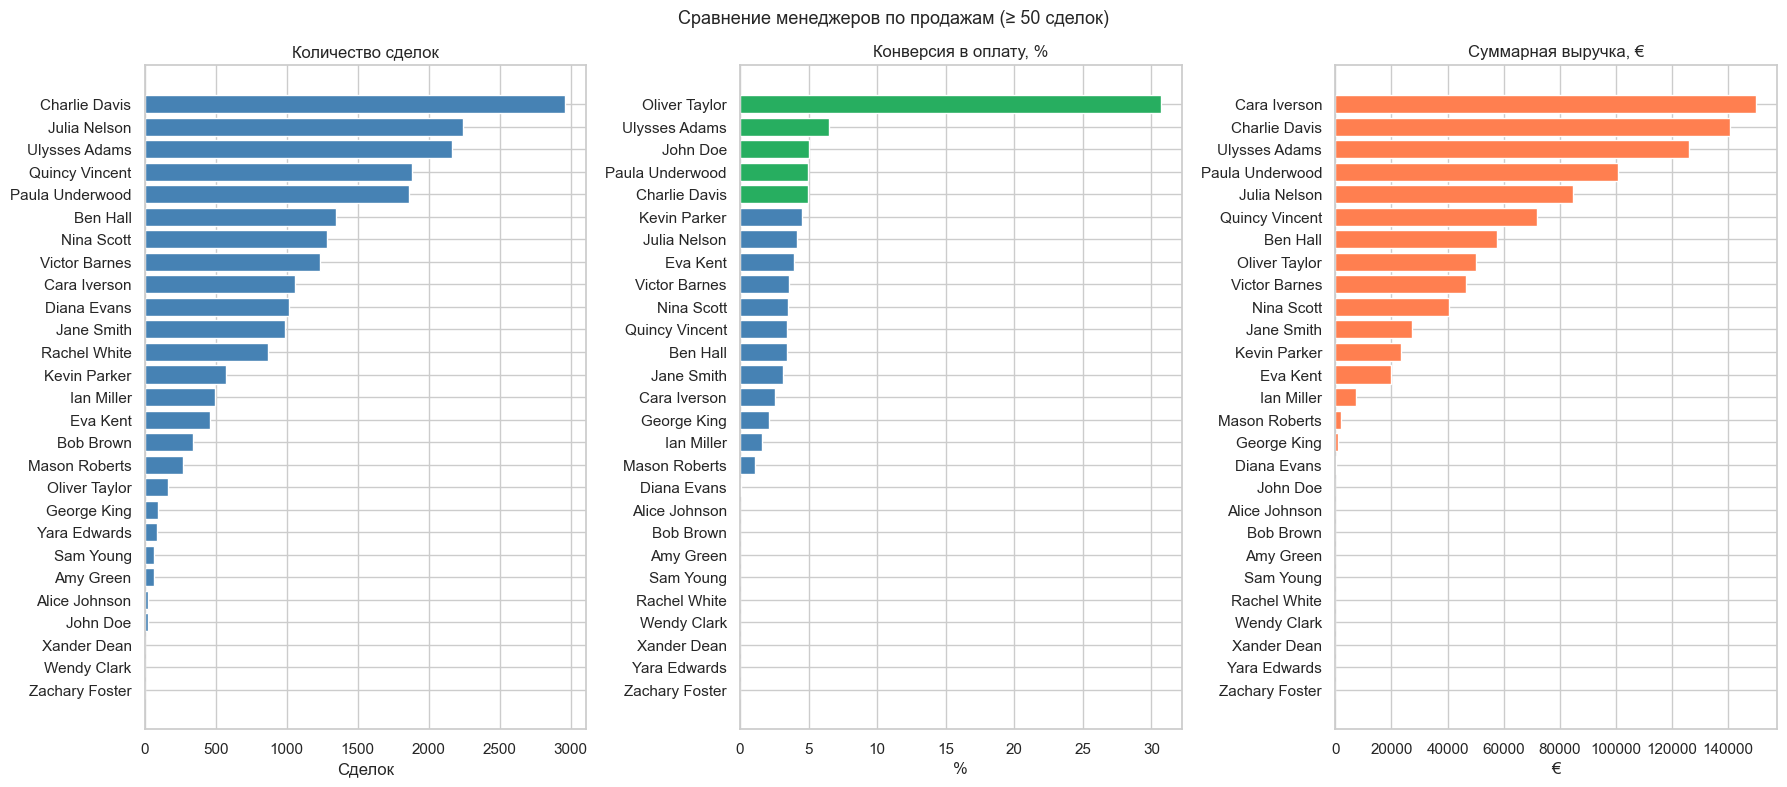

In [28]:
# Топ и антитоп по конверсии — все менеджеры
managers = manager_stats.copy()  # все 27 менеджеров

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# График 1: число сделок
sorted_by_deals = managers.sort_values('Сделок', ascending=False)
axes[0].barh(sorted_by_deals['Deal Owner Name'][::-1],
             sorted_by_deals['Сделок'][::-1], color='steelblue')
axes[0].set_title('Количество сделок')
axes[0].set_xlabel('Сделок')

# График 2: конверсия
sorted_by_conv = managers.sort_values('Конверсия %', ascending=False)
colors_conv = ['#27ae60' if i < 5 else ('#c0392b' if i >= len(sorted_by_conv) - 3
               else 'steelblue')
               for i in range(len(sorted_by_conv))]
axes[1].barh(sorted_by_conv['Deal Owner Name'][::-1],
             sorted_by_conv['Конверсия %'][::-1],
             color=colors_conv[::-1])
axes[1].set_title('Конверсия в оплату, %')
axes[1].set_xlabel('%')

# График 3: выручка
sorted_by_rev = managers.sort_values('Выручка', ascending=False)
axes[2].barh(sorted_by_rev['Deal Owner Name'][::-1],
             sorted_by_rev['Выручка'][::-1], color='coral')
axes[2].set_title('Суммарная выручка, €')
axes[2].set_xlabel('€')

plt.suptitle('Сравнение менеджеров по продажам (≥ 50 сделок)', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS + 'manager_comparison.png', dpi=100)
plt.show()


In [29]:
# Топ-3 и антитоп-3 по конверсии
top3 = managers.nlargest(3, 'Конверсия %')
bot3 = managers.nsmallest(3, 'Конверсия %')

print('ТОП-3 менеджера по конверсии:')
print(top3[['Deal Owner Name', 'Сделок', 'Оплат', 'Конверсия %']].to_string(index=False))
print()
print('АНТИТОП-3 менеджера по конверсии:')
print(bot3[['Deal Owner Name', 'Сделок', 'Оплат', 'Конверсия %']].to_string(index=False))


ТОП-3 менеджера по конверсии:
Deal Owner Name  Сделок  Оплат  Конверсия %
  Oliver Taylor   163.0   50.0        30.67
  Ulysses Adams  2165.0  141.0         6.51
       John Doe    20.0    1.0         5.00

АНТИТОП-3 менеджера по конверсии:
Deal Owner Name  Сделок  Оплат  Конверсия %
  Alice Johnson    25.0    0.0          0.0
      Bob Brown   337.0    0.0          0.0
      Amy Green    66.0    0.0          0.0


In [30]:
# Разброс конверсии — есть ли значимые различия между менеджерами?
conv_std = managers['Конверсия %'].std()
conv_mean = managers['Конверсия %'].mean()
print(f'Средняя конверсия по активным менеджерам (все менеджеры): {conv_mean:.2f}%')
print(f'Стандартное отклонение:                                 {conv_std:.2f}%')


Средняя конверсия по активным менеджерам (все менеджеры): 3.31%
Стандартное отклонение:                                 5.85%


**Вывод (раздел 7):** 27 менеджеров в команде. Средняя конверсия — 3,31%, стандартное отклонение — 5,85%. Лидер — Oliver Taylor (30,67%) — в 9,3 раза выше среднего. Девять менеджеров с нулевой конверсией при 1–871 сделках — критичная зона. Cara Iverson при конверсии 2,56% генерирует наибольшую выручку (149 900 €) — за счёт высокого среднего чека 5 552 € (работает с дорогими продуктами). Такой разброс говорит о системной проблеме: разные менеджеры работают в принципиально разных условиях — разные источники, разное качество лидов, разная нагрузка. Подробный разбор — в разделах 7.1–7.5.

### 7.1 Звонки и скорость ответа: как они влияют на конверсию?

Первый срез углубления: сколько звонков делает каждый менеджер на сделку и насколько быстро реагирует на новую заявку (SLA).

In [31]:
# Агрегаты для углублённого анализа менеджеров
calls_per_owner = calls.groupby('Call Owner Name', observed=True).size()
deals['SLA_h'] = deals['SLA (seconds)'] / 3600
sla_by_mgr = deals.groupby('Deal Owner Name', observed=True)['SLA_h'].median().round(1)

# Топ-источник по менеджеру — groupby вместо функции с циклом
def top_source_label(grp):
    top = grp.value_counts(normalize=True)
    return f'{top.index[0]} ({top.iloc[0]*100:.0f}%)'

top_src = (
    deals[deals['Deal Owner Name'].notna() & deals['Source'].notna()]
    .groupby('Deal Owner Name', observed=True)['Source']
    .apply(top_source_label)
)

# Собираем полный DataFrame через .map() — нет list comprehensions
mgr_deep = managers.copy()
mgr_deep['Звонков']        = mgr_deep.index.map(calls_per_owner).fillna(0).astype(int)
mgr_deep['Звонков/сделку'] = (mgr_deep['Звонков'] / mgr_deep['Сделок']).round(1)
mgr_deep['SLA медиана, ч'] = mgr_deep.index.map(sla_by_mgr)
mgr_deep['Топ-источник']   = mgr_deep.index.map(top_src).fillna('н/д')

cols = ['Deal Owner Name', 'Сделок', 'Оплат', 'Конверсия %',
        'Звонков', 'Звонков/сделку', 'SLA медиана, ч', 'Топ-источник']
print('Менеджеры — сводная таблица (сортировка по конверсии):')
display(mgr_deep[cols].sort_values('Конверсия %', ascending=False))


Менеджеры — сводная таблица (сортировка по конверсии):


,Deal Owner Name,Сделок,Оплат,Конверсия %,Звонков,Звонков/сделку,"SLA медиана, ч",Топ-источник
Deal Owner Name,,,,,,,,
Oliver Taylor,Oliver Taylor,163.0,50.0,30.67,10,0.1,3.0,Facebook Ads (29%)
Ulysses Adams,Ulysses Adams,2165.0,141.0,6.51,6085,2.8,4.9,Facebook Ads (21%)
John Doe,John Doe,20.0,1.0,5.00,2986,149.3,90.4,Organic (75%)
Paula Underwood,Paula Underwood,1862.0,93.0,4.99,4580,2.5,4.9,Facebook Ads (20%)
Charlie Davis,Charlie Davis,2963.0,148.0,4.99,7213,2.4,4.4,Facebook Ads (24%)
Kevin Parker,Kevin Parker,574.0,26.0,4.53,5406,9.4,12.6,Facebook Ads (30%)
Julia Nelson,Julia Nelson,2241.0,93.0,4.15,7446,3.3,7.1,Facebook Ads (23%)
Eva Kent,Eva Kent,459.0,18.0,3.92,498,1.1,4.3,Google Ads (22%)
Victor Barnes,Victor Barnes,1232.0,44.0,3.57,5439,4.4,5.5,Facebook Ads (23%)


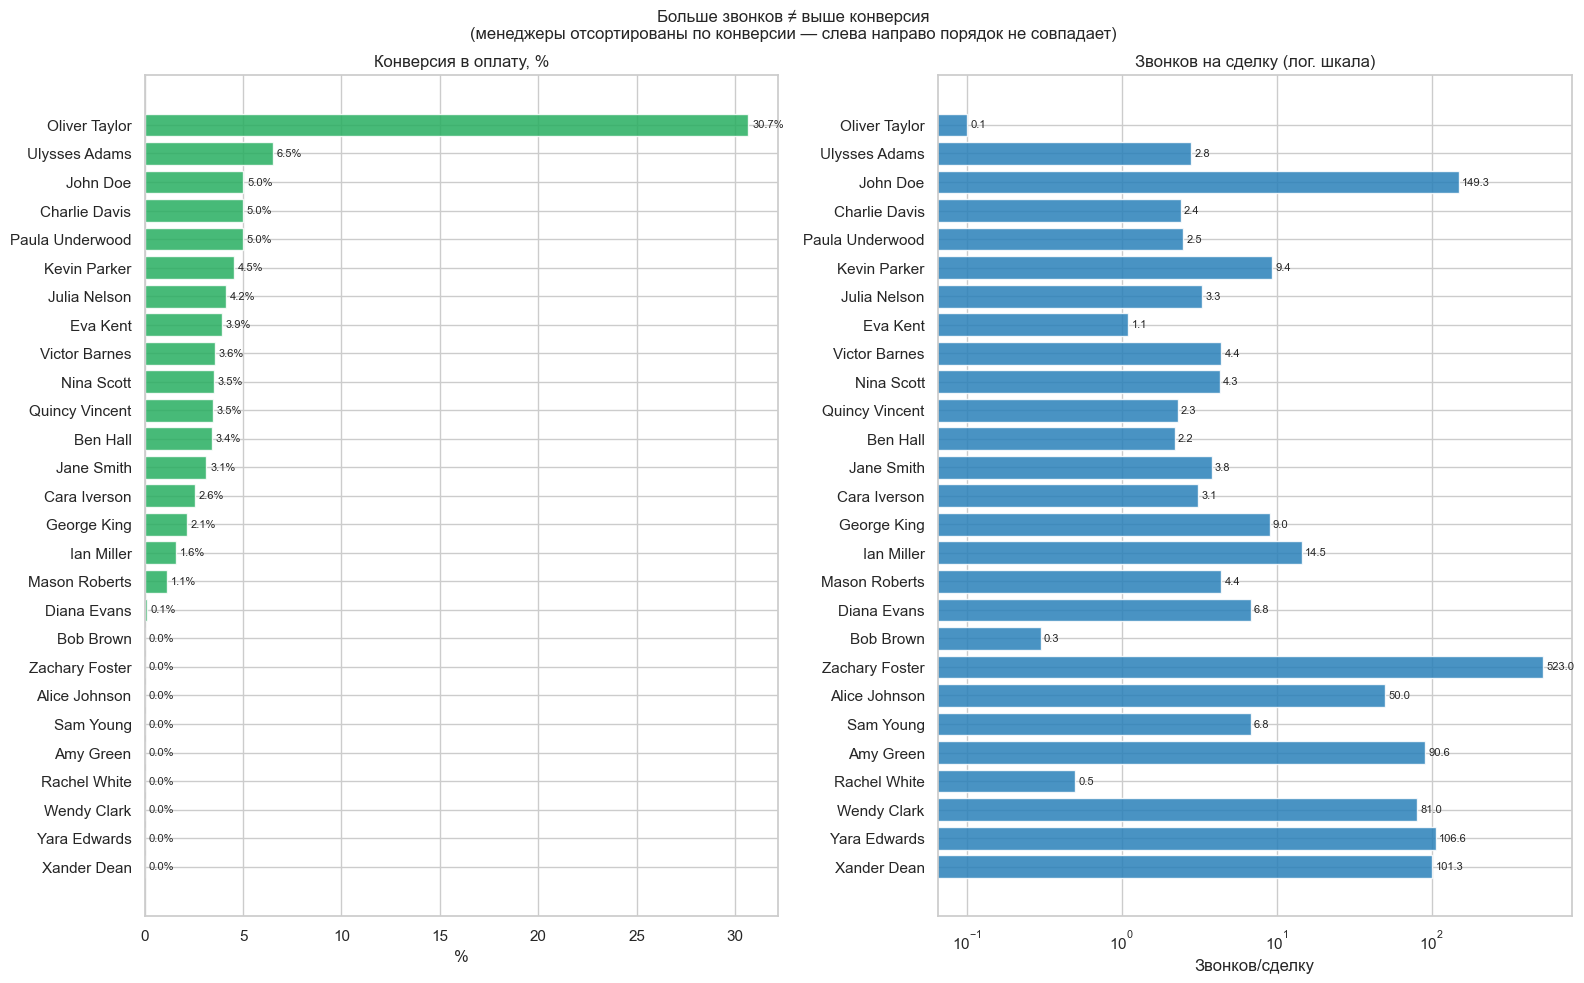

In [32]:
# Два barh рядом: конверсия % и звонков/сделку — сортировка по конверсии
# Логика: если звонки влияют на конверсию — правый график повторял бы порядок левого
mgr_sorted = mgr_deep.sort_values('Конверсия %', ascending=True)  # barh: лучшие сверху

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# --- Левый: конверсия % ---
bars0 = axes[0].barh(mgr_sorted['Deal Owner Name'], mgr_sorted['Конверсия %'],
                     color='#27ae60', alpha=0.85)
axes[0].set_title('Конверсия в оплату, %')
axes[0].set_xlabel('%')
for bar, val in zip(bars0, mgr_sorted['Конверсия %']):
    axes[0].text(max(bar.get_width(), 0) + 0.2, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=8)

# --- Правый: звонков/сделку (лог. шкала из-за выбросов, числа подписаны)
# Менеджеры с 0 звонков сдвигаем до 0.05 чтобы отобразить на лог. шкале
calls_plot = mgr_sorted['Звонков/сделку'].replace(0, 0.05)
bars1 = axes[1].barh(mgr_sorted['Deal Owner Name'], calls_plot,
                     color='#2980b9', alpha=0.85)
axes[1].set_xscale('log')
axes[1].set_title('Звонков на сделку (лог. шкала)')
axes[1].set_xlabel('Звонков/сделку')
for bar, val in zip(bars1, mgr_sorted['Звонков/сделку']):
    label = f'{val:.1f}' if val > 0 else '0'
    axes[1].text(bar.get_width() * 1.05, bar.get_y() + bar.get_height() / 2,
                 label, va='center', fontsize=8)

plt.suptitle('Больше звонков ≠ выше конверсия\n'
             '(менеджеры отсортированы по конверсии — слева направо порядок не совпадает)',
             fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS + 'managers_calls_vs_conversion.png', dpi=100)
plt.show()


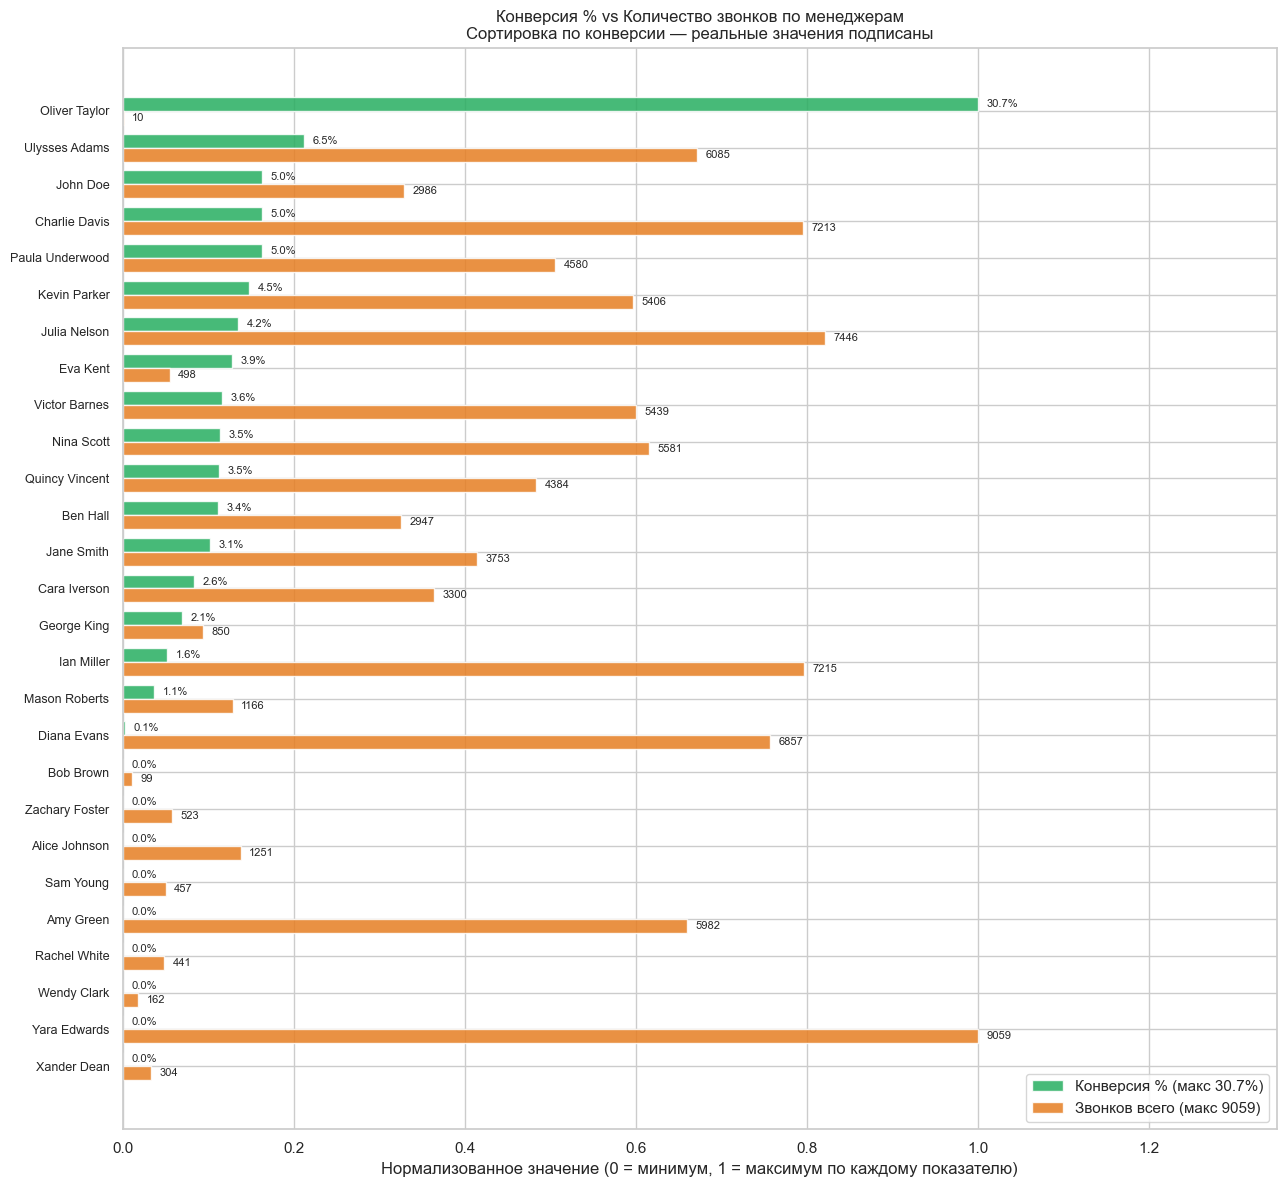

In [33]:
# Сгруппированный barh: для каждого менеджера два бара
# Зелёный — конверсия %, Оранжевый — общее количество звонков
# Оба нормализованы к шкале 0–1, реальные числа подписаны
mgr_sorted = mgr_deep.sort_values('Конверсия %', ascending=True)

max_conv  = mgr_sorted['Конверсия %'].max()
max_calls = mgr_sorted['Звонков'].max()
conv_norm  = mgr_sorted['Конверсия %'] / max_conv
calls_norm = mgr_sorted['Звонков']     / max_calls

names = mgr_sorted['Deal Owner Name'].tolist()
y = np.arange(len(names))
h = 0.38

fig, ax = plt.subplots(figsize=(13, 12))

bars_c = ax.barh(y + h/2, conv_norm,  h,
                 label=f'Конверсия % (макс {max_conv:.1f}%)', color='#27ae60', alpha=0.85)
bars_k = ax.barh(y - h/2, calls_norm, h,
                 label=f'Звонков всего (макс {max_calls:.0f})', color='#e67e22', alpha=0.85)

for bar, val in zip(bars_c, mgr_sorted['Конверсия %']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)
for bar, val in zip(bars_k, mgr_sorted['Звонков']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{int(val)}', va='center', fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(names, fontsize=9)
ax.set_xlim(0, 1.35)
ax.set_xlabel('Нормализованное значение (0 = минимум, 1 = максимум по каждому показателю)')
ax.set_title(
    'Конверсия % vs Количество звонков по менеджерам\n'
    'Сортировка по конверсии — реальные значения подписаны',
    fontsize=12
)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(PLOTS + 'managers_calls_grouped.png', dpi=100)
plt.show()


**Вывод (раздел 7.1):** Конверсия определяется не объёмом звонков, а их качеством. Лидер Oliver Taylor (30,7%) делает **0,1 звонка на сделку** — берёт тёплый лид, быстро отвечает (SLA 3 ч) и не тратит время на мёртвые контакты. Антилидеры — Yara Edwards (106,6 звонка/сделку) и Amy Green (90,6) — нулевая конверсия при сотнях звонков: это звонки по нецелевым лидам вхолостую. Аномалия: John Doe — 149,3 звонка на сделку (2 986 звонков на 20 сделок) — вероятно, технический артефакт CRM. Bob Brown реагирует быстрее всех (SLA 0,9 ч), но конверсия — 0%: скорость без качества лидов не помогает.

### 7.2 Распределение источников по менеджерам

Смотрим, с каких источников приходят лиды к каждому менеджеру. Если менеджер «заперт» в одном источнике — это риск: разные источники дают разное качество лидов.

In [34]:
# Распределение источников по менеджерам
mgr_names = managers.index.tolist()

src_mgr = (
    deals[deals['Deal Owner Name'].notna() & deals['Source'].notna() &
          deals['Deal Owner Name'].isin(mgr_names)]
    .groupby(['Deal Owner Name', 'Source'], observed=True).size()
    .unstack(fill_value=0)
)
src_pct = src_mgr.divide(src_mgr.sum(axis=1), axis=0).mul(100).round(1)

# Таблица: менеджеры × все источники, в каждом источнике — кол. и %
all_sources = src_mgr.columns.tolist()  # все 13 источников, топ не нужен

table_72 = pd.concat(
    {src: pd.DataFrame({'кол.': src_mgr[src], '%': src_pct[src]})
     for src in all_sources},
    axis=1
)
table_72.index.name = 'Менеджер'

print('Источники лидов по менеджерам (все источники):')
display(table_72)

Источники лидов по менеджерам (все источники):


Bloggers        CRM       Facebook Ads       Google Ads        \
                    кол.     % кол.     %         кол.     %       кол.     %   
Менеджер                                                                        
Alice Johnson          0   0.0    0   0.0            1   4.0         16  64.0   
Amy Green              2   3.0   37  56.1            8  12.1          6   9.1   
Ben Hall              65   4.8   89   6.6          263  19.6        322  23.9   
Bob Brown              2   0.6    0   0.0           74  22.0         86  25.5   
Cara Iverson          42   4.0   62   5.9          216  20.5        261  24.7   
Charlie Davis        200   6.7  223   7.5          716  24.2        573  19.3   
Diana Evans           66   6.5   66   6.5          284  28.0        195  19.2   
Eva Kent              20   4.4   34   7.4           95  20.7        100  21.8   
George King           12  12.8    3   3.2           26  27.7         20  21.3   
Ian Miller            35   7.0   54  10.9          128  25.8         87  17.5   
Jane Smith            41   4.1   42   4.3          269  27.2        233  23.6   
John Doe               0   0.0    2  10.0            0   0.0          0   0.0   
Julia Nelson          90   4.0  222   9.9          510  22.8        446  19.9   
Kevin Parker          27   4.7   64  11.1          173  30.1        116  20.2   
Mason Roberts         18   6.7    6   2.2           85  31.7         56  20.9   
Nina Scott            81   6.3  129  10.1          287  22.4        183  14.3   
Oliver Taylor         14   8.6    7   4.3           47  28.8         32  19.6   
Paula Underwood      116   6.2  114   6.1          380  20.4        335  18.0   
Quincy Vincent        57   3.0  123   6.5          440  23.4        387  20.5   
Rachel White          35   4.0   30   3.4           60   6.9         91  10.4   
Sam Young              4   6.0    0   0.0           11  16.4          5   7.5   
Ulysses Adams         90   4.2  228  10.5          463  21.4        412  19.0   
Victor Barnes         67   5.4   81   6.6          280  22.7        249  20.2   
Wendy Clark            1  50.0    0   0.0            0   0.0          0   0.0   
Xander Dean            0   0.0    0   0.0            1  33.3          0   0.0   
Yara Edwards           1   1.2   40  47.1           15  17.6         11  12.9   
Zachary Foster         0   0.0    0   0.0            0   0.0          0   0.0   

                Offline       ... Telegram posts        Test      Tiktok Ads  \
                   кол.    %  ...           кол.      % кол.    %       кол.   
Менеджер                      ...                                              
Alice Johnson         0  0.0  ...              4   16.0    0  0.0          2   
Amy Green             0  0.0  ...              0    0.0    0  0.0          2   
Ben Hall              1  0.1  ...             67    5.0   16  1.2        120   
Bob Brown             0  0.0  ...             29    8.6    0  0.0         29   
Cara Iverson          0  0.0  ...             50    4.7   31  2.9        142   
Charlie Davis         0  0.0  ...            143    4.8    8  0.3        294   
Diana Evans           0  0.0  ...             52    5.1    3  0.3         93   
Eva Kent              0  0.0  ...             21    4.6    7  1.5         58   
George King           0  0.0  ...              5    5.3    0  0.0          7   
Ian Miller            0  0.0  ...             15    3.0    1  0.2         36   
Jane Smith            0  0.0  ...             59    6.0    0  0.0         90   
John Doe              0  0.0  ...              0    0.0    0  0.0          0   
Julia Nelson          0  0.0  ...             83    3.7   22  1.0        213   
Kevin Parker          0  0.0  ...             20    3.5    1  0.2         45   
Mason Roberts         0  0.0  ...              7    2.6    0  0.0         27   
Nina Scott            0  0.0  ...             67    5.2    4  0.3        135   
Oliver Taylor         0  0.0  ...              2    1.2    0  0.0

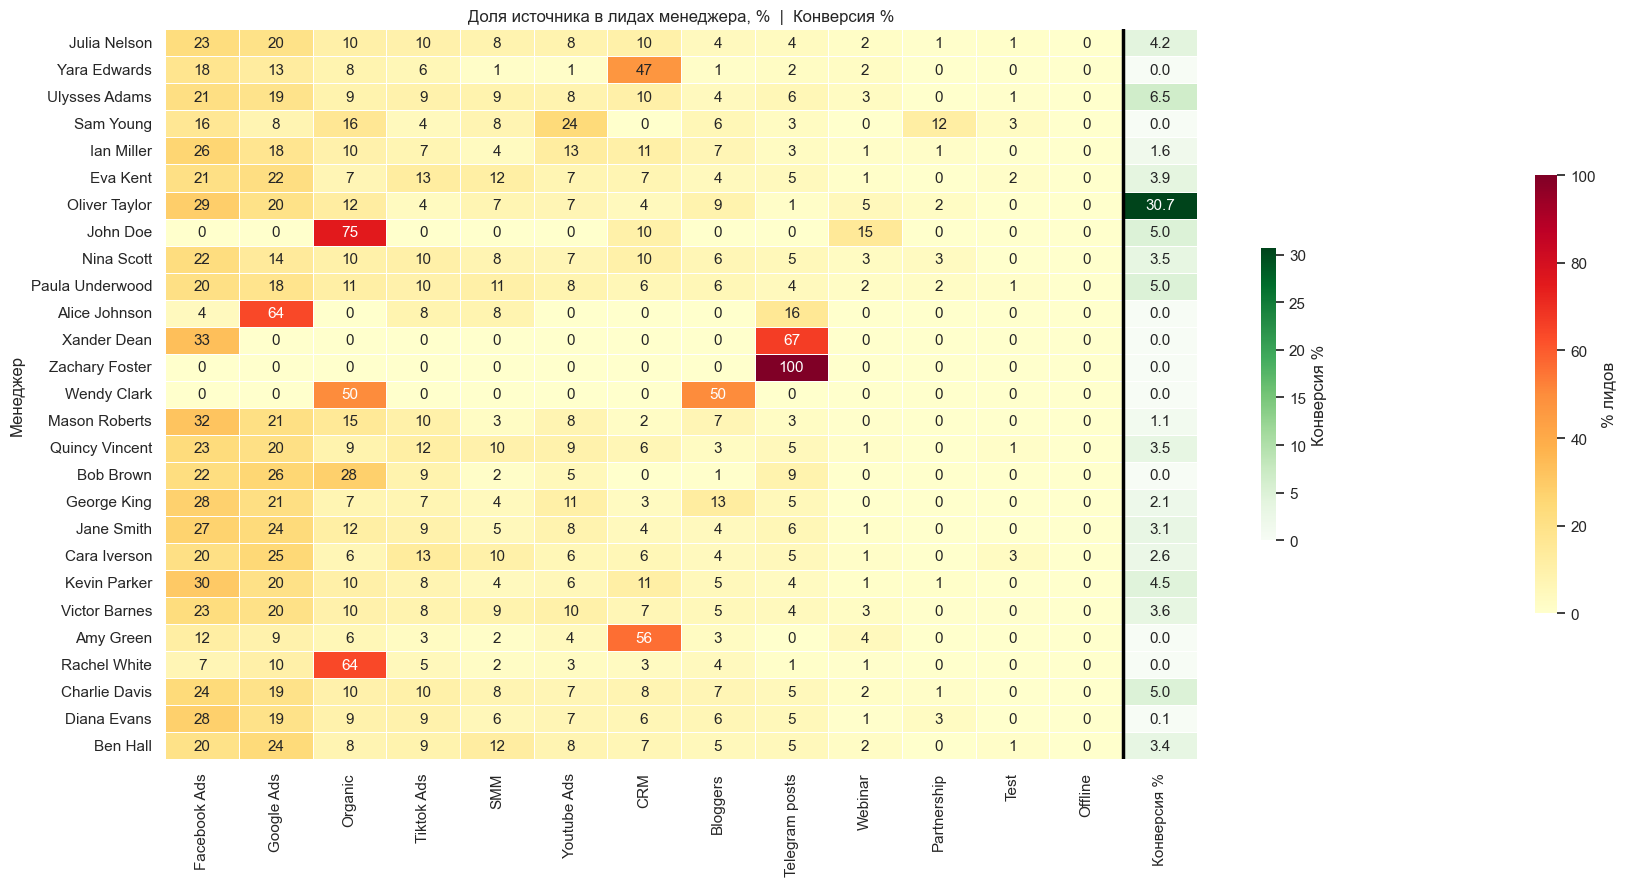

In [35]:
# Тепловая карта: источники + конверсия как отдельный столбик
cols_by_volume = src_mgr.sum().sort_values(ascending=False).index
hm_data = src_pct[cols_by_volume].copy()
hm_data = hm_data.loc[hm_data.sum(axis=1).sort_values(ascending=False).index]

# Добавляем конверсию как последний столбец
hm_data['Конверсия %'] = managers.loc[hm_data.index, 'Конверсия %']

# Маска: конверсионный столбец рисуем другим цветом (Blues)
n_src = len(cols_by_volume)  # 13 источников
mask_src  = pd.DataFrame(False, index=hm_data.index, columns=hm_data.columns)
mask_conv = pd.DataFrame(False, index=hm_data.index, columns=hm_data.columns)
mask_src['Конверсия %']  = True   # скрываем конверсию с первого слоя
mask_conv.iloc[:, :n_src] = True   # скрываем источники со второго слоя

fig, ax = plt.subplots(figsize=(18, 9))

# Слой 1: источники (YlOrRd)
sns.heatmap(hm_data, mask=mask_src, annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': '% лидов', 'shrink': 0.6},
            vmin=0, vmax=100)

# Слой 2: конверсия (Greens) — своя шкала
sns.heatmap(hm_data, mask=mask_conv, annot=True, fmt='.1f',
            cmap='Greens', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Конверсия %', 'shrink': 0.4},
            vmin=0, vmax=hm_data['Конверсия %'].max())

# Вертикальная линия-разделитель перед столбцом конверсии
ax.axvline(x=n_src, color='black', linewidth=2.5)

ax.set_title('Доля источника в лидах менеджера, %  |  Конверсия %', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Менеджер')
plt.tight_layout()
plt.savefig(PLOTS + 'manager_source_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()


**Вывод (раздел 7.2):** Большинство менеджеров работают со смешанным пулом лидов — Facebook Ads занимает 17–32%, Google Ads 14–26% у типичного менеджера. Однако у ряда менеджеров выражена концентрация на одном источнике: Alice Johnson — 64% лидов из Google Ads, Rachel White — 64% из Organic, Amy Green — 56% из CRM, Yara Edwards — 47% из CRM. Все четыре имеют нулевую конверсию. CRM как источник — внутренние или реактивированные лиды низкого качества. Исключение: John Doe — 75% лидов из Organic при конверсии 5% (20 сделок — выборка мала). Привязка к одному «проблемному» источнику без диверсификации — один из факторов нулевой конверсии.

### 7.3 Качество входящих лидов по менеджеру

Менеджеры получают лиды с разным качеством (оценка A/B/C/D/E в CRM). Проверяем: влияет ли доля «горячих» лидов (A+B) на конверсию менеджера?

> **Примечание по данным:** Согласно FAQ задания, поле `Quality` заполняется самим менеджером по продажам субъективно. Это важная оговорка: мы анализируем не объективное качество распределённых лидов, а то, как сам менеджер оценивает свою работу с клиентами. Влияние самооценки на конверсию — самостоятельный интересный вопрос, но выводы нельзя использовать для управленческих решений без внешней верификации оценки.

,% качественных (A+B),Конверсия %
Deal Owner Name,,
Oliver Taylor,57.8,30.67
John Doe,22.2,5.00
Kevin Parker,20.4,4.53
Eva Kent,14.6,3.92
Mason Roberts,14.1,1.12
Jane Smith,13.0,3.14
Ben Hall,12.9,3.42
Quincy Vincent,12.6,3.45
Julia Nelson,11.1,4.15


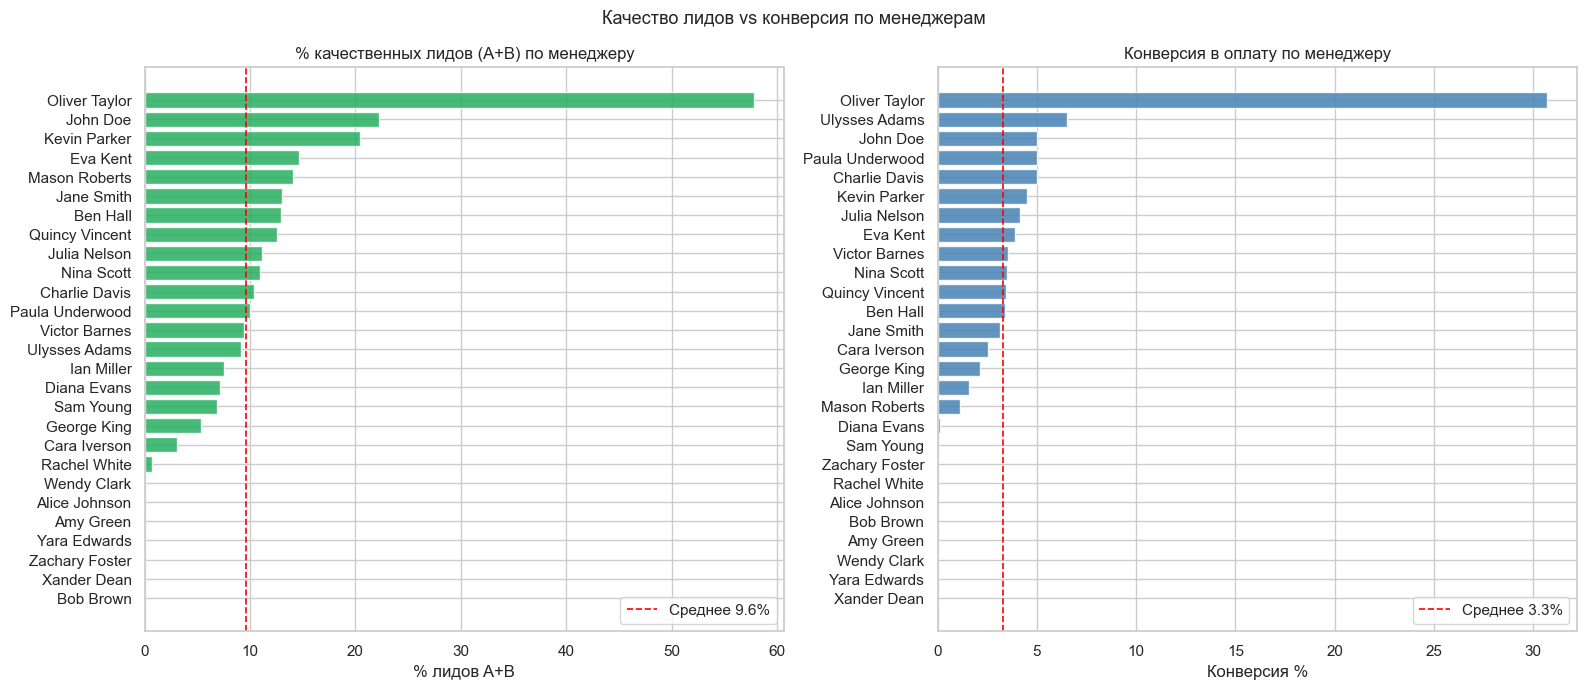

In [36]:
# Доля качественных лидов (A+B) у каждого менеджера
deals['is_quality'] = deals['Quality'].isin(['A - High', 'B - Medium'])
qual_mgr = (
    deals[deals['Deal Owner Name'].notna() & deals['Quality'].notna() &
          deals['Deal Owner Name'].isin(managers.index)]
    .groupby('Deal Owner Name', observed=True)['is_quality']
    .mean() * 100
).round(1).rename('% качественных A+B')

# Соединяем с конверсией
qual_conv = pd.DataFrame({
    '% качественных (A+B)': qual_mgr,
    'Конверсия %': managers['Конверсия %']
}).sort_values('% качественных (A+B)', ascending=False)
display(qual_conv)

# Визуализация: два бара рядом (качество и конверсия)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

order = qual_conv.sort_values('% качественных (A+B)', ascending=True).index
axes[0].barh(order, qual_conv.loc[order, '% качественных (A+B)'], color='#27ae60', alpha=0.85)
axes[0].axvline(qual_mgr.mean(), color='red', linestyle='--', linewidth=1.2,
                label=f'Среднее {qual_mgr.mean():.1f}%')
axes[0].set_title('% качественных лидов (A+B) по менеджеру')
axes[0].set_xlabel('% лидов A+B')
axes[0].legend()

order2 = qual_conv.sort_values('Конверсия %', ascending=True).index
axes[1].barh(order2, qual_conv.loc[order2, 'Конверсия %'], color='steelblue', alpha=0.85)
axes[1].axvline(managers['Конверсия %'].mean(), color='red', linestyle='--', linewidth=1.2,
                label=f'Среднее {managers["Конверсия %"].mean():.1f}%')
axes[1].set_title('Конверсия в оплату по менеджеру')
axes[1].set_xlabel('Конверсия %')
axes[1].legend()

plt.suptitle('Качество лидов vs конверсия по менеджерам', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS + 'manager_quality_vs_conv.png', dpi=100)
plt.show()

**Вывод (раздел 7.3):** Прослеживается прямая связь между долей качественных лидов и конверсией. Oliver Taylor — 57,8% лидов категории A+B (в 5 раз выше среднего по команде) и конверсия 30,7%. Менеджеры с нулевой конверсией (Rachel White, Amy Green, Bob Brown, Yara Edwards) имеют 0% качественных лидов — они работают исключительно с категориями D и E (нецелевой трафик).

**Ограничение анализа:** Однако, как следует из FAQ задания, поле `Quality` заполняется самим менеджером субъективно. Корреляция между «качеством лидов» и конверсией может отражать не реальное распределение трафика, а согласованность самооценки менеджера с результатом. Менеджер с высокой конверсией склонен ставить A/B тем лидам, которые оплатили, и D/E — тем, кто отказал. Таким образом, интерпретировать этот анализ как «проблему распределения лидов» без внешней верификации нельзя.

### 7.4 Выручка и средний чек по менеджеру

Конверсия — это эффективность, но бизнес считает деньги. Смотрим, кто реально генерирует выручку и почему средний чек так сильно отличается.

Выручка и средний чек по менеджерам:


,Сделок,Оплат,Конверсия %,Выручка,"Средний чек, €"
Deal Owner Name,,,,,
Cara Iverson,1056.0,27.0,2.56,149900.0,5552.0
Charlie Davis,2963.0,148.0,4.99,140750.0,951.0
Ulysses Adams,2165.0,141.0,6.51,126100.0,894.0
Paula Underwood,1862.0,93.0,4.99,100650.0,1082.0
Julia Nelson,2241.0,93.0,4.15,84551.0,909.0
Quincy Vincent,1884.0,65.0,3.45,71900.0,1106.0
Ben Hall,1345.0,46.0,3.42,57700.0,1254.0
Oliver Taylor,163.0,50.0,30.67,50250.0,1005.0
Victor Barnes,1232.0,44.0,3.57,46600.0,1059.0


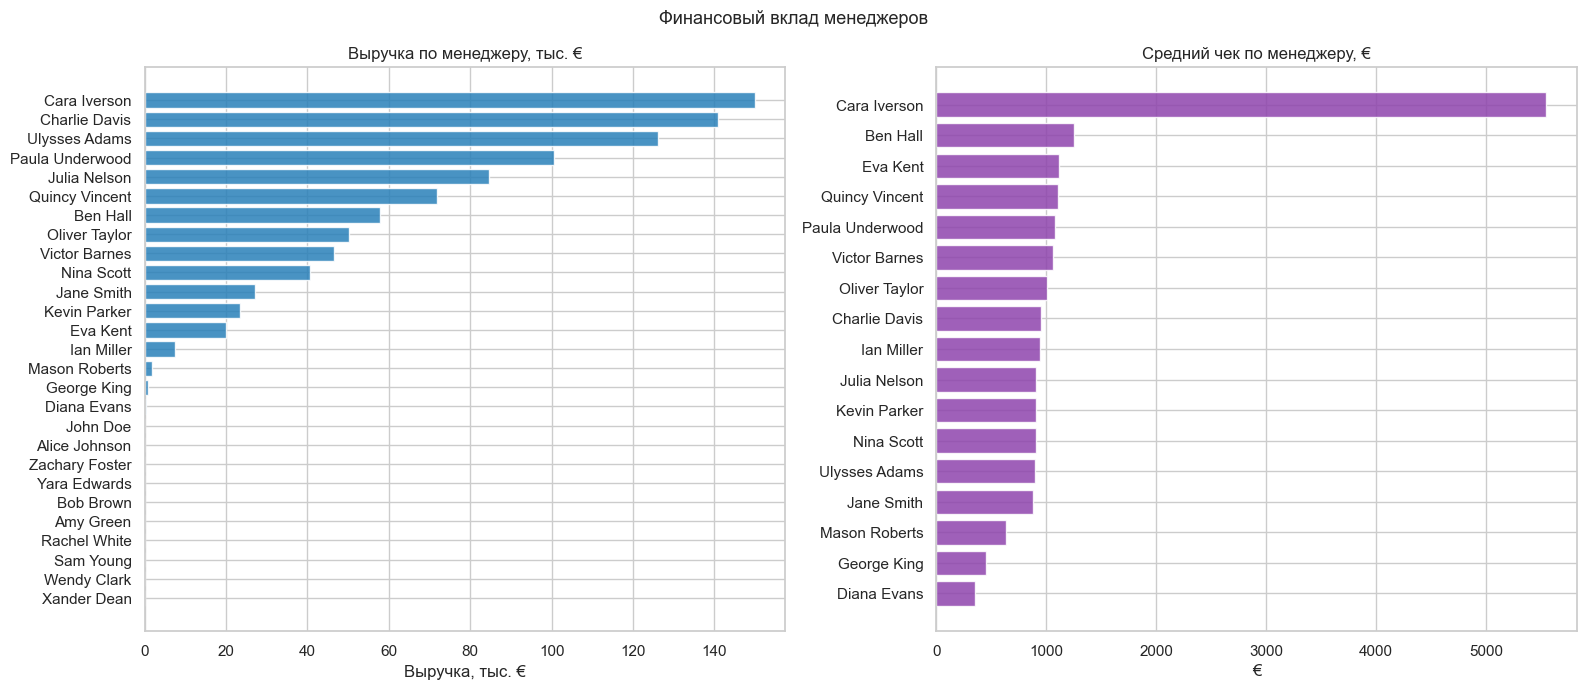

In [37]:
# Выручка и средний чек по менеджеру
rev_mgr = managers[['Сделок','Оплат','Конверсия %','Выручка']].copy()
rev_mgr['Средний чек, €'] = (rev_mgr['Выручка'] / rev_mgr['Оплат'].replace(0, np.nan)).round(0)
rev_mgr = rev_mgr.sort_values('Выручка', ascending=False)
print('Выручка и средний чек по менеджерам:')
display(rev_mgr)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Выручка
order_r = rev_mgr.sort_values('Выручка', ascending=True).index
axes[0].barh(order_r, rev_mgr.loc[order_r, 'Выручка'] / 1000,
             color='#2980b9', alpha=0.85)
axes[0].set_title('Выручка по менеджеру, тыс. €')
axes[0].set_xlabel('Выручка, тыс. €')

# Средний чек (только у кого есть оплаты)
chek = rev_mgr[rev_mgr['Средний чек, €'].notna() & (rev_mgr['Средний чек, €'] > 0)].copy()
order_c = chek.sort_values('Средний чек, €', ascending=True).index
axes[1].barh(order_c, chek.loc[order_c, 'Средний чек, €'],
             color='#8e44ad', alpha=0.85)
axes[1].set_title('Средний чек по менеджеру, €')
axes[1].set_xlabel('€')

plt.suptitle('Финансовый вклад менеджеров', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS + 'manager_revenue.png', dpi=100)
plt.show()

**Вывод (раздел 7.4):** Топ-3 по выручке: Cara Iverson (149 900 €), Charlie Davis (140 750 €), Ulysses Adams (126 100 €). При этом их конверсия — 2,56%, 4,99%, 6,51% соответственно: Cara Iverson при низкой конверсии компенсирует это средним чеком 5 552 € — работает с дорогими продуктами (курс по 10 000+ €). Oliver Taylor — 8-й по выручке (50 250 €), но это 50 оплат при 163 сделках: высокая конверсия + стандартный чек 1 005 €. Семь менеджеров с нулевой выручкой при суммарно 1 459 сделках — прямые потери бизнеса от неэффективного распределения лидов.

### 7.5 SLA: скорость первого ответа vs конверсия

SLA (seconds) — время от создания заявки до первого контакта менеджера. Проверяем: быстрый ответ = выше конверсия?

SLA медиана vs Конверсия (сортировка по SLA):


,"SLA медиана, ч",Конверсия %
Deal Owner Name,,
Bob Brown,0.9,0.00
Jane Smith,2.5,3.14
Oliver Taylor,3.0,30.67
Diana Evans,3.7,0.10
Eva Kent,4.3,3.92
Charlie Davis,4.4,4.99
Paula Underwood,4.9,4.99
Ulysses Adams,4.9,6.51
George King,5.1,2.13


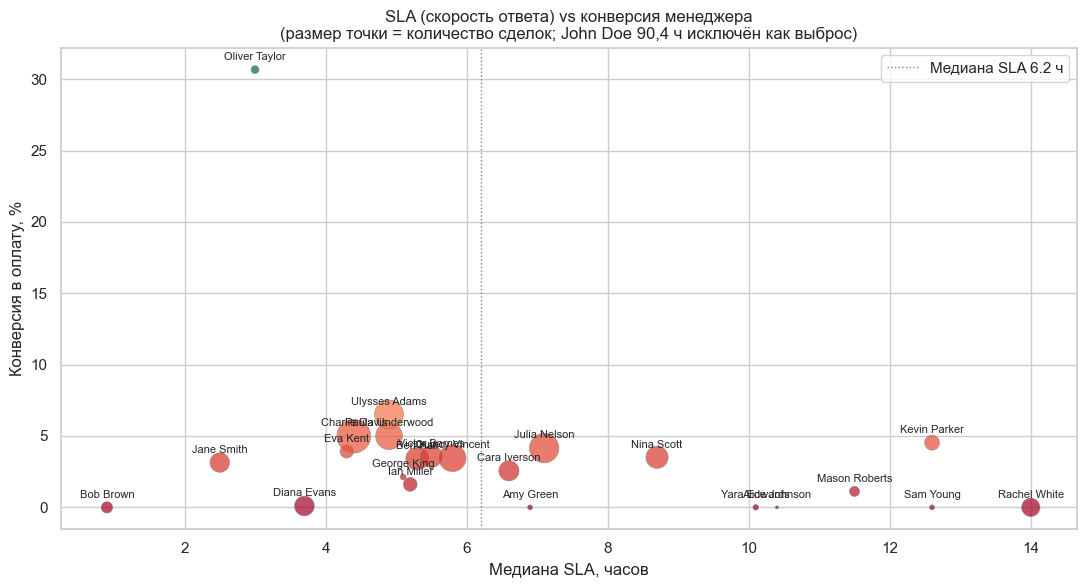

In [38]:
# SLA медиана по менеджеру + конверсия
deals['SLA_h'] = deals['SLA (seconds)'] / 3600
sla_mgr = (
    deals[deals['Deal Owner Name'].notna()]
    .groupby('Deal Owner Name', observed=True)['SLA_h']
    .median().round(1)
    .rename('SLA медиана, ч')
)
sla_conv = pd.DataFrame({
    'SLA медиана, ч': sla_mgr,
    'Конверсия %': managers['Конверсия %']
}).dropna().sort_values('SLA медиана, ч')

print('SLA медиана vs Конверсия (сортировка по SLA):')
display(sla_conv)

# Scatter: SLA vs конверсия
fig, ax = plt.subplots(figsize=(11, 6))

# Исключаем John Doe (SLA 90 ч — экстремальный выброс)
plot_data = sla_conv[sla_conv['SLA медиана, ч'] <= 20].copy()
sc = ax.scatter(plot_data['SLA медиана, ч'], plot_data['Конверсия %'],
                s=managers.loc[plot_data.index, 'Сделок'] / 5,
                alpha=0.7, c=plot_data['Конверсия %'], cmap='RdYlGn',
                edgecolors='gray', linewidth=0.5)
for name, row in plot_data.iterrows():
    ax.annotate(name, (row['SLA медиана, ч'], row['Конверсия %']),
                fontsize=8, ha='center', xytext=(0, 7), textcoords='offset points')

ax.axvline(sla_mgr.median(), color='gray', linestyle=':', linewidth=1,
           label=f'Медиана SLA {sla_mgr.median():.1f} ч')
ax.set_xlabel('Медиана SLA, часов')
ax.set_ylabel('Конверсия в оплату, %')
ax.set_title('SLA (скорость ответа) vs конверсия менеджера\n(размер точки = количество сделок; John Doe 90,4 ч исключён как выброс)')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS + 'manager_sla_vs_conv.png', dpi=100)
plt.show()

**Вывод (раздел 7.5):** Скорость ответа **не является единственным фактором** конверсии. Bob Brown реагирует быстрее всех (медиана SLA 0,9 ч), но конверсия — 0%. Oliver Taylor — SLA 3 ч, конверсия 30,7%. Jane Smith — SLA 2,5 ч, конверсия 3,1%. Картина: быстрый ответ необходим, но недостаточен — он работает только в связке с качественным лидом. Менеджеры с нулевой конверсией отвечают быстро на нецелевые лиды, которые всё равно не купят. Аномалия: John Doe — SLA 90,4 ч (почти 4 дня) при конверсии 5% — возможно, специфика работы с конкретным типом лидов, не типичный случай.

### 7.6 Составной рейтинг менеджеров

Отдельные метрики (конверсия, выручка, скорость) дают разных «лучших». Cara Iverson лидирует по выручке, но не по конверсии. Oliver Taylor лидирует по конверсии, но у него небольшой объём. Чтобы получить **единственный ответ** на вопрос «кто самый эффективный?», строим составной рейтинг.

#### Метрики и веса

| Метрика | Вес | Логика |
|---|---|---|
| Конверсия % | 50% | Главная бизнес-метрика — умеет ли менеджер закрывать лиды |
| Выручка | 30% | Абсолютный денежный вклад в бизнес |
| Звонков/сделку (инверт.) | 20% | Эффективность: меньше звонков на сделку = лучше |

#### Как считается рейтинг

1. **Percentile rank** — для каждой метрики вычисляем, какое место занимает менеджер среди всех 27 в диапазоне 0–1.
   Например, если менеджер занимает 20-е место из 27 по конверсии → его percentile = 20/27 ≈ 0,74 (74-й процентиль).
2. Для метрики «Звонков/сделку» **инвертируем**: 1 − percentile, потому что меньше звонков = лучше.
3. **Взвешенная сумма**: `Рейтинг = (r_конверсия × 0,50 + r_выручка × 0,30 + r_эффективность × 0,20) × 100`
4. Итог: **0–100 баллов**. 100 = абсолютный лидер по всем трём метрикам одновременно.

In [39]:
# Составной рейтинг менеджеров (percentile rank, взвешенный)
score_df = managers[['Конверсия %', 'Выручка', 'Сделок']].copy()
score_df['Звонков/сделку'] = mgr_deep['Звонков/сделку']

score_df['r_conv']    = score_df['Конверсия %'].rank(pct=True)
score_df['r_revenue'] = score_df['Выручка'].rank(pct=True)
score_df['r_eff']     = (1 - score_df['Звонков/сделку'].rank(pct=True))  # меньше = лучше

score_df['Рейтинг (0–100)'] = (
    score_df['r_conv']    * 0.50 +
    score_df['r_revenue'] * 0.30 +
    score_df['r_eff']     * 0.20
).mul(100).round(1)

rating = score_df[['Рейтинг (0–100)', 'Конверсия %', 'Выручка', 'Звонков/сделку', 'Сделок']]    .sort_values('Рейтинг (0–100)', ascending=False)
rating.index.name = 'Менеджер'

print('ТОП-3 — эталон для команды:')
display(rating.head(3))
print()
print('Полный рейтинг (27 менеджеров):')
display(rating)

ТОП-3 — эталон для команды:


,Рейтинг (0–100),Конверсия %,Выручка,Звонков/сделку,Сделок
Менеджер,,,,,
Oliver Taylor,91.5,30.67,50250.0,0.1,163.0
Ulysses Adams,89.3,6.51,126100.0,2.8,2165.0
Charlie Davis,87.2,4.99,140750.0,2.4,2963.0



Полный рейтинг (27 менеджеров):


,Рейтинг (0–100),Конверсия %,Выручка,Звонков/сделку,Сделок
Менеджер,,,,,
Oliver Taylor,91.5,30.67,50250.0,0.1,163.0
Ulysses Adams,89.3,6.51,126100.0,2.8,2165.0
Charlie Davis,87.2,4.99,140750.0,2.4,2963.0
Paula Underwood,84.3,4.99,100650.0,2.5,1862.0
Julia Nelson,76.3,4.15,84551.0,3.3,2241.0
Quincy Vincent,71.5,3.45,71900.0,2.3,1884.0
Eva Kent,70.7,3.92,20000.0,1.1,459.0
Ben Hall,69.3,3.42,57700.0,2.2,1345.0
Cara Iverson,68.5,2.56,149900.0,3.1,1056.0


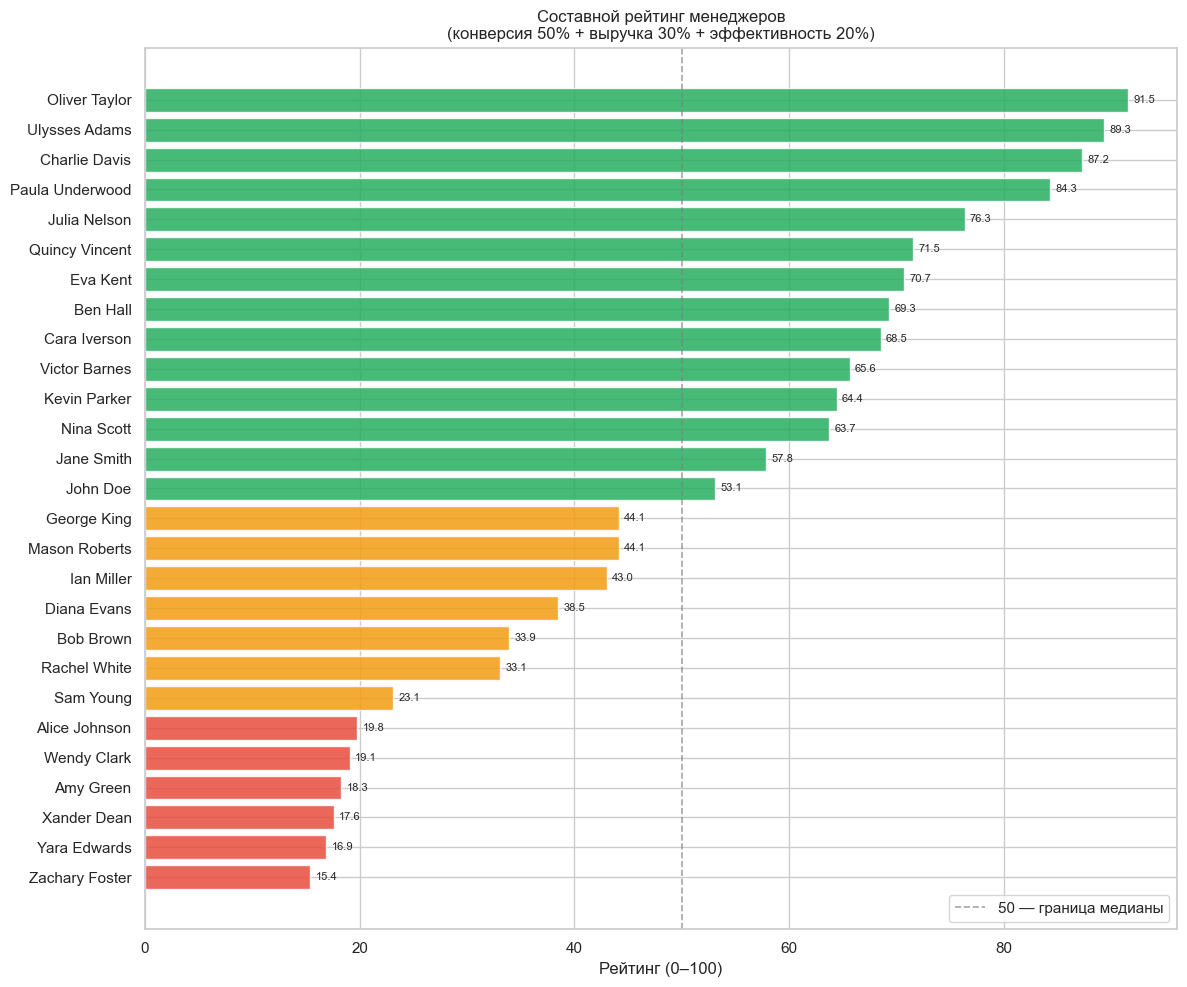

In [40]:
# Визуализация: рейтинг по всем 27 менеджерам
plot_df = rating.sort_values('Рейтинг (0–100)', ascending=True)

colors = [
    '#e74c3c' if v < 20 else '#f39c12' if v < 50 else '#27ae60'
    for v in plot_df['Рейтинг (0–100)']
]

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(plot_df.index, plot_df['Рейтинг (0–100)'], color=colors, alpha=0.85)

for bar, val in zip(bars, plot_df['Рейтинг (0–100)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=8)

ax.axvline(x=50, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label='50 — граница медианы')
ax.set_title('Составной рейтинг менеджеров\n(конверсия 50% + выручка 30% + эффективность 20%)')
ax.set_xlabel('Рейтинг (0–100)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(PLOTS + 'manager_composite_rating.png', dpi=100)
plt.show()

**Вывод (раздел 7.6 — Составной рейтинг):**

**ТОП-3 — эталон команды:**
1. **Oliver Taylor** — 91,5 балла: конверсия 30,7%, 0,1 звонка на сделку. Берёт тёплый лид и закрывает с минимальными усилиями — максимальная эффективность.
2. **Ulysses Adams** — 89,3: конверсия 6,5%, выручка 126 100 €, 2,8 звонков/сделку. Работает с большим объёмом (2 165 сделок) и сохраняет высокую конверсию.
3. **Charlie Davis** — 87,2: конверсия 5,0%, наибольшая выручка команды 140 750 €, 2,4 звонков/сделку. Лидер по деньгам при умеренной нагрузке.

Что объединяет ТОП-3: **конверсия выше среднего + разумное число контактов на сделку**. Они не гонятся за количеством звонков.

**Системная проблема:** 7 менеджеров набрали < 20 баллов — нулевая конверсия при 1–85 сделках и 50–523 звонках/сделку. Это не индивидуальная ошибка: такой результат говорит о системном сбое на уровне распределения лидов или отсутствия стандарта работы (скриптов, обучения). Перераспределение входящего потока в пользу ТОП-менеджеров или целевое обучение аутсайдеров — приоритетная точка роста.

## 8. Продукты и платежи

### 8.1 Выручка и конверсия по продуктам

In [41]:
# Анализируем только сделки с заполненным продуктом
with_product = deals[deals['Product'].notna()].copy()
n_products = deals['Product'].nunique()
print(f'Всего уникальных продуктов: {n_products}')
print()

product_stats = (
    with_product.groupby('Product', observed=True)
    .apply(lambda x: pd.Series({
        'Сделок': len(x),
        'Оплат': ((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum(),
        'Конверсия %': round(((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum() / len(x) * 100, 2),
        'Средний чек': x.loc[
            (x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()
            & (~x['Initial Amount Paid'].isin([0, 1, 9])),
            'Initial Amount Paid'
        ].median(),
        'Выручка': x.loc[
            (x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna(),
            'Initial Amount Paid'
        ].sum()
    }), include_groups=False)
    .reset_index()
    .sort_values('Оплат', ascending=False)
)

print('Статистика по всем продуктам:')
print(product_stats.to_string(index=False))


Всего уникальных продуктов: 5

Статистика по всем продуктам:
            Product  Сделок  Оплат  Конверсия %  Средний чек  Выручка
  Digital Marketing  1990.0  474.0        23.82       1000.0 531900.0
       UX/UI Design  1022.0  229.0        22.41       1000.0 275100.0
      Web Developer   575.0  137.0        23.83       1000.0 143350.0
Find yourself in IT     4.0    1.0        25.00          NaN      1.0
     Data Analytics     1.0    0.0         0.00          NaN      0.0


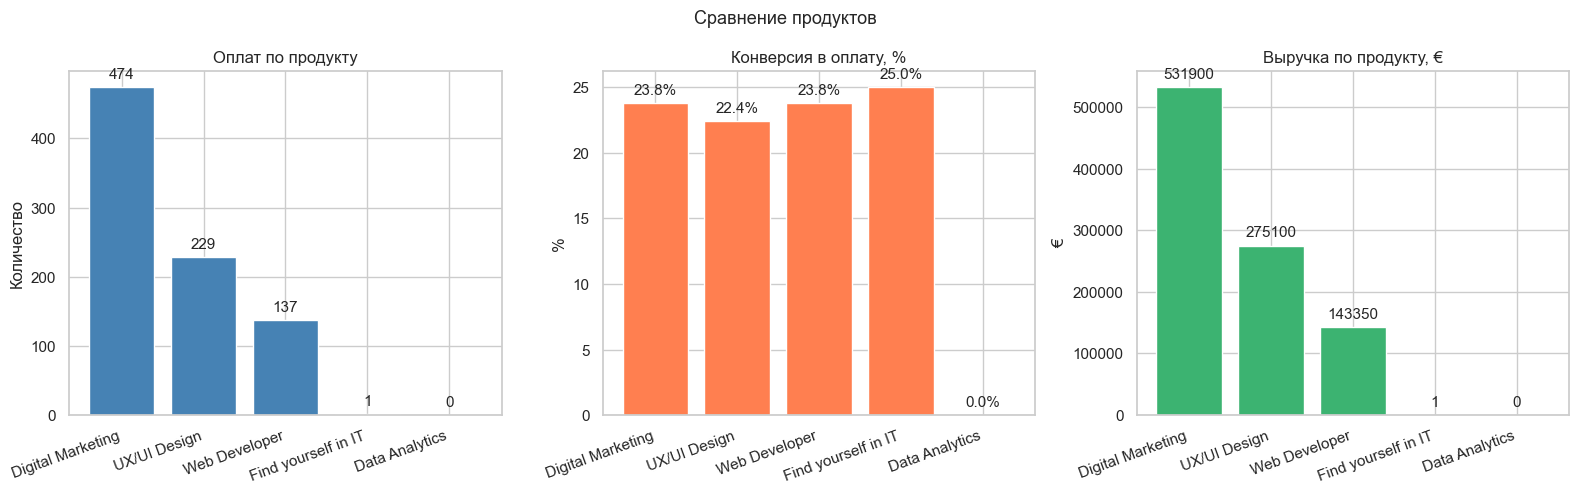

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Число оплат по продукту
bars0 = axes[0].bar(product_stats['Product'], product_stats['Оплат'],
                    color='steelblue')
axes[0].set_title('Оплат по продукту')
axes[0].set_ylabel('Количество')
axes[0].bar_label(bars0, fmt='%d', padding=4)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20, ha='right')

# Конверсия по продукту
bars1 = axes[1].bar(product_stats['Product'], product_stats['Конверсия %'],
                    color='coral')
axes[1].set_title('Конверсия в оплату, %')
axes[1].set_ylabel('%')
axes[1].bar_label(bars1, fmt='%.1f%%', padding=4)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha='right')

# Выручка по продукту
bars2 = axes[2].bar(product_stats['Product'],
                    product_stats['Выручка'].fillna(0),
                    color='mediumseagreen')
axes[2].set_title('Выручка по продукту, €')
axes[2].set_ylabel('€')
axes[2].bar_label(bars2, fmt='%.0f', padding=4)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=20, ha='right')

plt.suptitle('Сравнение продуктов', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS + 'product_comparison.png', dpi=100)
plt.show()


**Вывод (раздел 8.1):** Всего 5 продуктов. Три основных — Digital Marketing (474 оплаты), UX/UI Design (229), Web Developer (137) — с одинаковым медианным чеком 1 000 €. Конверсия у всех трёх практически одинакова (~22–24%), что говорит об одинаковой «горячести» аудитории, а не о преимуществах конкретного продукта. Data Analytics и Find yourself in IT — единичные наблюдения, выводы по ним нерепрезентативны. Единственное что отличается между продуктами это количетсво оплаченых сделок и выручка


### 8.2 Типы оплаты (Payment Type)

In [43]:
# Payment Type заполняется только у части оплаченных сделок
paid = deals[(deals['Stage'] == 'Payment Done') & deals['Initial Amount Paid'].notna()].copy()
total_paid = len(paid)
print(f'Всего оплаченных сделок: {total_paid}')
print(f'Из них с заполненным Payment Type: {paid["Payment Type"].notna().sum()} '
      f'({paid["Payment Type"].notna().mean()*100:.0f}%)')
print(f'Без Payment Type: {paid["Payment Type"].isna().sum()} сделок — тип оплаты не зафиксирован')
print()

# Статистика по типам оплаты (только среди оплат с заполненным типом)
paid_typed = paid[paid['Payment Type'].notna()].copy()

pt_stats = (
    paid_typed.groupby('Payment Type', observed=True)
    .apply(lambda x: pd.Series({
        'Кол-во оплат': len(x),
        '% от оплат с типом': round(len(x) / len(paid_typed) * 100, 1),
        'Выручка, €': round(x['Initial Amount Paid'].sum(), 0),
        'Средний чек, €': round(x['Initial Amount Paid'].mean(), 0),
    }), include_groups=False)
    .sort_values('Кол-во оплат', ascending=False)
    .reset_index()
)
print('Статистика по типам оплаты:')
display(pt_stats)

Всего оплаченных сделок: 843
Из них с заполненным Payment Type: 364 (43%)
Без Payment Type: 479 сделок — тип оплаты не зафиксирован

Статистика по типам оплаты:


,Payment Type,Кол-во оплат,% от оплат с типом,"Выручка, €","Средний чек, €"
0,Recurring Payments,250.0,68.7,111100.0,444.0
1,One Payment,113.0,31.0,232751.0,2060.0
2,Reservation,1.0,0.3,100.0,100.0


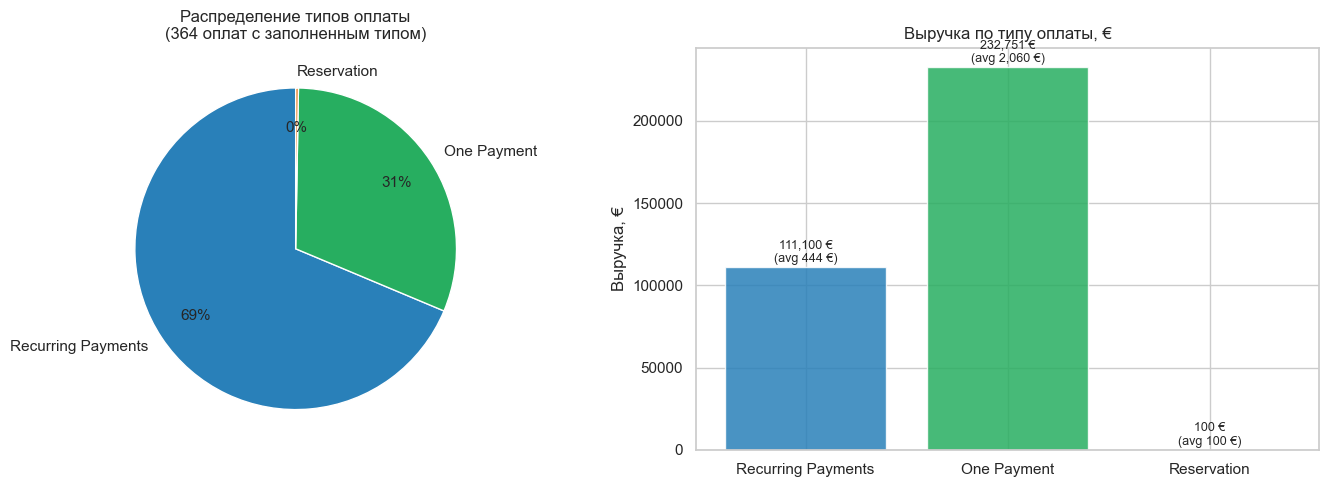

In [44]:
# Визуализация: два графика — распределение и выручка
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

types = pt_stats['Payment Type'].tolist()
counts = pt_stats['Кол-во оплат'].tolist()
revenues = pt_stats['Выручка, €'].tolist()
colors_pt = ['#2980b9', '#27ae60', '#e67e22']

# Левый: количество оплат (пирог)
axes[0].pie(counts, labels=types, autopct='%1.0f%%', colors=colors_pt,
            startangle=90, pctdistance=0.75)
axes[0].set_title(f'Распределение типов оплаты\n({len(paid_typed)} оплат с заполненным типом)')

# Правый: выручка по типам
bars = axes[1].bar(types, revenues, color=colors_pt, alpha=0.85)
axes[1].set_title('Выручка по типу оплаты, €')
axes[1].set_ylabel('Выручка, €')
for bar, rev, avg in zip(bars, revenues, pt_stats['Средний чек, €'].tolist()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{rev:,.0f} €\n(avg {avg:,.0f} €)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS + 'payment_type_breakdown.png', dpi=100)
plt.show()

**Вывод (раздел 8.2):** Поле `Payment Type` заполнено у 364 из 843 оплаченных сделок (43%) — остальные 57% не имеют зафиксированного типа. Среди тех, где тип указан: **Recurring Payments — 68,7%** по количеству (250 сделок), но **One Payment генерирует в 2 раза больше выручки** (232 751 € против 111 100 €) благодаря среднему чеку 2 060 € vs 444 €. То есть рассрочка (Recurring) — массовый инструмент для недорогих курсов, единоразовая оплата (One Payment) — меньше клиентов, но дороже. Конверсия от всех лидов: Recurring 1,16%, One Payment 0,52%. Reservation — единичный случай (1 сделка).

### 8.3 Типы обучения (Education Type)

In [45]:
# Education Type — формат обучения. Смотрим распределение, конверсию и средний чек
et = deals[deals['Education Type'].notna()].copy()
print(f'Education Type заполнен у {len(et)} из {len(deals)} сделок ({len(et)/len(deals)*100:.1f}%)')
print(f'Уникальных типов обучения: {et["Education Type"].nunique()}')
print()

edu_stats = (
    et.groupby('Education Type', observed=True)
    .apply(lambda x: pd.Series({
        'Сделок': len(x),
        'Оплат': ((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum(),
        'Конверсия %': round(((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum() / len(x) * 100, 2),
        'Медиана чека': x.loc[(x['Stage'] == 'Payment Done')
                              & x['Initial Amount Paid'].notna(), 'Initial Amount Paid'].median()
    }), include_groups=False)
    .sort_values('Сделок', ascending=False)
    .reset_index()
)
print('Конверсия и средний чек по типу обучения:')
print(edu_stats.to_string(index=False))

Education Type заполнен у 3299 из 21593 сделок (15.3%)
Уникальных типов обучения: 2

Конверсия и средний чек по типу обучения:
Education Type  Сделок  Оплат  Конверсия %  Медиана чека
       Morning  2895.0  662.0        22.87        1000.0
       Evening   404.0  171.0        42.33         350.0


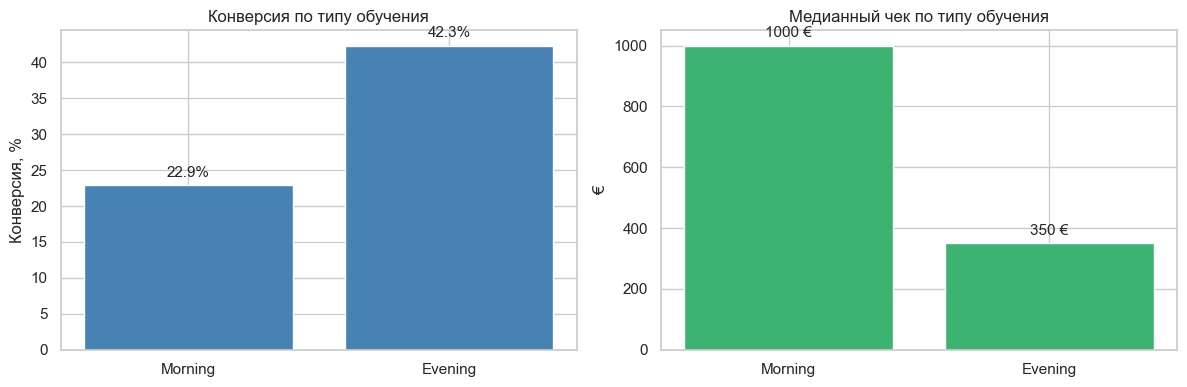

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Конверсия по типу обучения
bars0 = axes[0].bar(edu_stats['Education Type'], edu_stats['Конверсия %'],
                    color='steelblue')
axes[0].set_title('Конверсия по типу обучения')
axes[0].set_ylabel('Конверсия, %')
axes[0].bar_label(bars0, fmt='%.1f%%', padding=4)

# Медианный чек по типу обучения
bars1 = axes[1].bar(edu_stats['Education Type'], edu_stats['Медиана чека'],
                    color='mediumseagreen')
axes[1].set_title('Медианный чек по типу обучения')
axes[1].set_ylabel('€')
axes[1].bar_label(bars1, fmt='%.0f €', padding=4)

plt.tight_layout()
plt.savefig(PLOTS + 'education_type.png', dpi=100)
plt.show()

In [47]:
# Кросс-таблица: тип обучения × тип оплаты (только оплаченные сделки с обоими полями)
paid = deals[(deals['Stage'] == 'Payment Done') & deals['Initial Amount Paid'].notna()]
both = paid[paid['Education Type'].notna() & paid['Payment Type'].notna()]
print(f'Оплат с заполненными Education Type и Payment Type: {len(both)} из {len(paid)}')
print()

ct_pct = pd.crosstab(both['Education Type'], both['Payment Type'],
                     normalize='index').mul(100).round(1)
ct_pct.columns.name = None
ct_pct.index.name = 'Education Type'
print('Распределение типов оплаты по формату обучения, %:')
display(ct_pct)

Оплат с заполненными Education Type и Payment Type: 360 из 843

Распределение типов оплаты по формату обучения, %:


,One Payment,Recurring Payments,Reservation
Education Type,,,
Evening,25.1,74.9,0.0
Morning,35.4,64.0,0.5


**Вывод (раздел 8.3):** `Education Type` заполнен у 3 299 сделок (15,3%) — важная оговорка: 85% лидов поля не имеют, среди них конверсия близка к нулю. Morning/Evening — более «тёплые» клиенты, уже выбравшие формат обучения, поэтому их конверсия (22,9% и 42,3%) в 5–10 раз выше общей по воронке (4%). Сравнивать Morning и Evening между собой можно, экстраполировать на весь бизнес — нельзя.

Morning — основной сегмент (2 895 лидов, 662 оплаты), медианный чек 1 000 €. Evening — меньше по объёму (404 лида, 171 оплата), конверсия выше (42,3%), медианный чек 350 €. Причина низкого чека подтверждается данными: 74,9% вечерних студентов платят рассрочкой (Recurring Payments) против 64,0% у утренних — каждый платёж при рассрочке меньше полной стоимости курса, отсюда и низкая медиана. Evening конвертирует лучше, но приносит меньше денег с клиента — расширять этот формат имеет смысл только при росте объёма лидов в сегменте.

### 8.4 Причины потери сделок (Lost Reason)

In [48]:
# Lost Reason — ключ к пониманию, почему клиенты уходят
lost_deals = deals[deals['Stage'] == 'Lost']
lost_reason = lost_deals['Lost Reason'].value_counts()
n_lost_reasons = lost_deals['Lost Reason'].nunique()

print(f'Всего причин потери: {n_lost_reasons} уникальных')
print()
print('Причины потери сделок:')
print(lost_reason.to_string())


Всего причин потери: 21 уникальных

Причины потери сделок:
Lost Reason
Doesn't Answer                             4074
Changed Decision                           2122
Duplicate                                  1746
Non target                                 1736
Stopped Answering                          1556
Invalid number                             1460
Expensive                                   614
needs time to think                         606
Conditions are not suitable                 524
Inadequate                                  174
Gutstein refusal                            163
Considering a different direction in IT     148
Not for myself                              145
Does not speak English                      138
Didn't leave an application                 131
Next stream                                 131
Thought for free                            110
Does not know how to use a computer          49
Went to Rivals                               47
The contract did 

In [49]:
# Группируем причины потери по бизнес-типу
reason_groups = {
    'Недоступность':     ["Doesn't Answer", 'Stopped Answering', 'Invalid number'],
    'Возражения':        ['Changed Decision', 'Expensive', 'needs time to think',
                          'Conditions are not suitable', 'Not for myself',
                          'Thought for free', 'The contract did not fit'],
    'Нецелевой трафик':  ['Non target', 'Inadequate', 'Does not speak English',
                          "Didn't leave an application",
                          'Does not know how to use a computer', 'Refugee'],
    'Дубликаты':         ['Duplicate'],
    'Конкуренты/отложил':['Gutstein refusal',
                          'Considering a different direction in IT',
                          'Next stream', 'Went to Rivals'],
}

# Инвертируем словарь: причина → группа
reason_to_group = {r: g for g, reasons in reason_groups.items() for r in reasons}
lost_deals = deals[deals['Stage'] == 'Lost'].copy()
lost_deals['Группа'] = lost_deals['Lost Reason'].map(reason_to_group).fillna('Прочее')

group_stats = (
    lost_deals.groupby('Группа', observed=False)
    .size()
    .rename('Кол-во')
    .reset_index()
)
total_lost = len(lost_deals)
group_stats['%'] = (group_stats['Кол-во'] / total_lost * 100).round(1)
group_stats = group_stats.sort_values('Кол-во', ascending=False)

print(f'Всего проигранных сделок: {total_lost}')
print()
print('Причины потери по бизнес-группам:')
display(group_stats)

Всего проигранных сделок: 15743

Причины потери по бизнес-группам:


,Группа,Кол-во,%
3,Недоступность,7090,45.0
0,Возражения,4142,26.3
4,Нецелевой трафик,2229,14.2
1,Дубликаты,1746,11.1
2,Конкуренты/отложил,489,3.1
5,Прочее,47,0.3


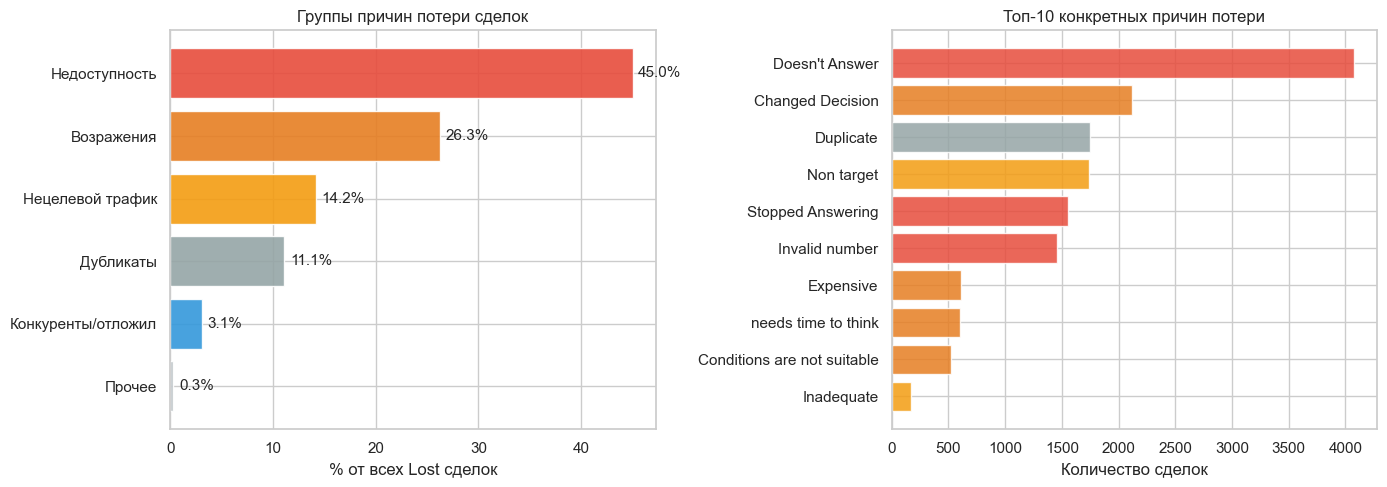

In [50]:
# Визуализация: группы причин потери
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_g = {
    'Недоступность':     '#e74c3c',
    'Возражения':        '#e67e22',
    'Нецелевой трафик':  '#f39c12',
    'Дубликаты':         '#95a5a6',
    'Конкуренты/отложил':'#3498db',
    'Прочее':            '#bdc3c7',
}
g_order = group_stats.sort_values('%', ascending=False)
bar_colors = [colors_g.get(g, '#bdc3c7') for g in g_order['Группа']]

# Левый: горизонтальный бар
bars = axes[0].barh(g_order['Группа'][::-1], g_order['%'][::-1], color=bar_colors[::-1], alpha=0.9)
axes[0].set_title('Группы причин потери сделок')
axes[0].set_xlabel('% от всех Lost сделок')
axes[0].bar_label(bars, fmt='%.1f%%', padding=4)

# Правый: топ-10 конкретных причин
top10 = lost_deals['Lost Reason'].value_counts().head(10)
top10_colors = [colors_g.get(reason_to_group.get(r, 'Прочее'), '#bdc3c7') for r in top10.index]
axes[1].barh(top10.index[::-1], top10.values[::-1], color=top10_colors[::-1], alpha=0.85)
axes[1].set_title('Топ-10 конкретных причин потери')
axes[1].set_xlabel('Количество сделок')

plt.tight_layout()
plt.savefig(PLOTS + 'lost_reason_groups.png', dpi=100)
plt.show()

**Вывод (раздел 8.4):** 15 743 проигранные сделки разбиваются на 4 бизнес-группы с разными причинами и разными решениями.

**Недоступность — 45% потерь** («Doesn't Answer» + «Stopped Answering» + «Invalid number»). Клиент существует, но до него не дозвонились. Это процессная проблема — не продукт и не цена. Решение: снизить SLA первого контакта, увеличить число попыток дозвониться, проверять номера при вводе лида.

**Возражения — 26% потерь** («Changed Decision», «Expensive», «Needs time to think» и др.). Клиент взаимодействовал с менеджером, но не купил. Это работа с возражениями — скрипты продаж, follow-up последовательности. Важно: «Expensive» только 3,9% — цена не главная проблема, давление на скидки не решит 96% потерь.

**Нецелевой трафик — 14% потерь** («Non target», «Inadequate», «Doesn't speak English» и др.). Неправильная аудитория приходит из рекламы. Решение: точнее настраивать таргетинг, добавить квалификацию лида до передачи менеджеру.

**Дубликаты — 11% потерь** — технический мусор в CRM. Это не настоящие потери, а отсутствие автоматической дедупликации на входе.

## 9. География: города

Смотрим географическое распределение лидов по городам.

> **По пункту ТЗ 3.7.2:** ТЗ предусматривает анализ влияния уровня знания немецкого на успешность сделок. Поле `Level of Deutsch` в текущем виде не стандартизировано — 215 уникальных значений из-за произвольного ввода (`B1`, `б1`, `В1`, `beginner` и др.). Для полноценного анализа необходима стандартизация в CRM. Подробнее — в разделе 9.2.

### 9.1 Распределение по городам

In [51]:
# Стандартизация поля City
# Три записи содержат полный адрес вместо города — исправляем вручную
city_fixes = {
    'Karl-Liebknecht str. 24, Hildburghausen, Thüringen': 'Hildburghausen',
    'Poland , Gdansk , Al. Grunwaldzka 7, ap. 1a':        'Gdansk',
    'Vor Ebersbach 1, 77761 Schiltach':                   'Schiltach',
}
deals['City'] = deals['City'].replace(city_fixes)

n_with_city = deals['City'].notna().sum()
n_unique    = deals['City'].nunique()
pct         = n_with_city / len(deals) * 100
print(f'City заполнен у {n_with_city} из {len(deals)} сделок ({pct:.1f}%)')
print(f'Уникальных городов после стандартизации: {n_unique}')

City заполнен у 2163 из 21593 сделок (10.0%)
Уникальных городов после стандартизации: 875


In [52]:
# Статистика по городам: лиды, оплаты, конверсия, выручка
city_deals = deals[deals['City'].notna()].copy()

city_stats = (
    city_deals.groupby('City', observed=True)
    .apply(lambda x: pd.Series({
        'Лидов':       len(x),
        'Оплат':       ((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum(),
        'Конверсия %': round(((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum()
                             / len(x) * 100, 2),
        'Выручка, €':  x.loc[(x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna(),
                              'Initial Amount Paid'].sum().round(0),
    }), include_groups=False)
    .sort_values('Лидов', ascending=False)
    .reset_index()
)

top15_share = city_stats.head(15)['Лидов'].sum() / city_stats['Лидов'].sum() * 100
print(f'Всего городов: {len(city_stats)}')
print()
print('Все города по числу лидов:')
display(city_stats.set_index('City'))

Всего городов: 875

Все города по числу лидов:


,Лидов,Оплат,Конверсия %,"Выручка, €"
City,,,,
Berlin,182.0,78.0,42.86,85350.0
München,74.0,27.0,36.49,30600.0
Hamburg,62.0,22.0,35.48,23150.0
Leipzig,45.0,18.0,40.00,16150.0
Nürnberg,45.0,9.0,20.00,11500.0
...,...,...,...,...
Zerbst,1.0,0.0,0.00,0.0
Zetel,1.0,0.0,0.00,0.0
Zinnowitz,1.0,1.0,100.00,500.0


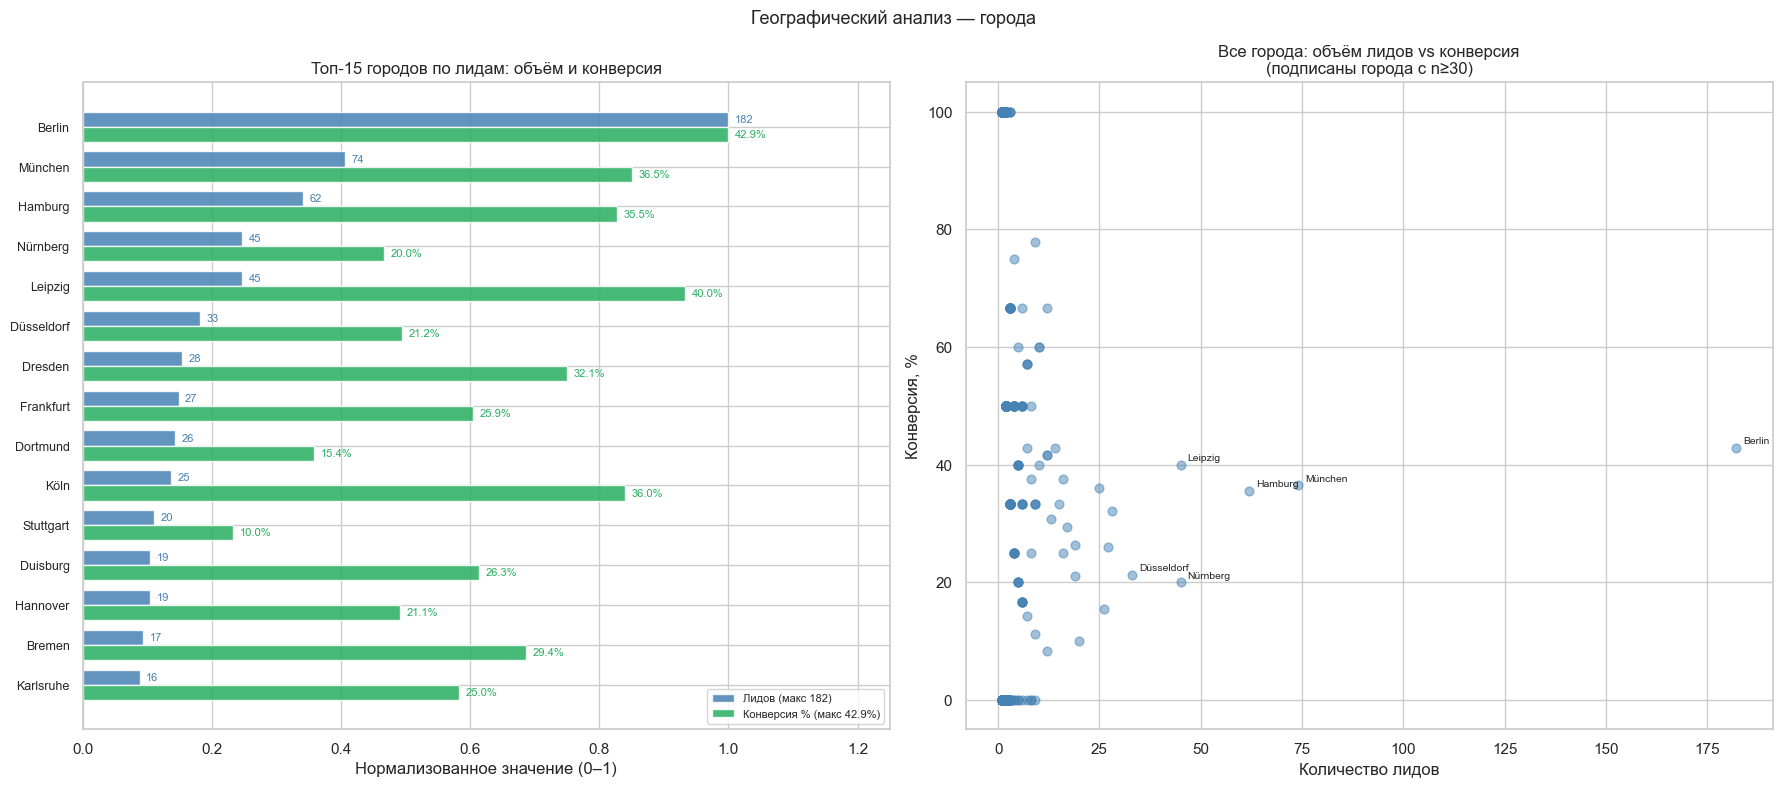

In [53]:
# График 1: топ-15 по лидам — два бара рядом (объём + конверсия)
top15 = city_stats.head(15).copy()
max_leads = top15['Лидов'].max()
max_conv  = top15['Конверсия %'].max()

top15_sorted = top15.sort_values('Лидов', ascending=True)
names = top15_sorted['City'].tolist()
y = np.arange(len(names))
bar_height = 0.38  # высота одного бара; два бара на строку → смещение ±bar_height/2

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Левый: группированный barh
bars_l = axes[0].barh(y + bar_height/2, top15_sorted['Лидов'] / max_leads,
                      bar_height, color='steelblue', alpha=0.85,
                      label=f'Лидов (макс {max_leads:.0f})')
bars_c = axes[0].barh(y - bar_height/2, top15_sorted['Конверсия %'] / max_conv,
                      bar_height, color='#27ae60', alpha=0.85,
                      label=f'Конверсия % (макс {max_conv:.1f}%)')

for bar, val in zip(bars_l, top15_sorted['Лидов']):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}', va='center', fontsize=8, color='steelblue')
for bar, val in zip(bars_c, top15_sorted['Конверсия %']):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=8, color='#27ae60')

axes[0].set_yticks(y)
axes[0].set_yticklabels(names, fontsize=9)
axes[0].set_xlabel('Нормализованное значение (0–1)')
axes[0].set_title('Топ-15 городов по лидам: объём и конверсия')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].set_xlim(0, 1.25)

# Правый: scatter — все города, X=лиды, Y=конверсия
axes[1].scatter(city_stats['Лидов'], city_stats['Конверсия %'],
                alpha=0.5, color='steelblue', s=40)

for _, row in city_stats[city_stats['Лидов'] >= 30].iterrows():
    axes[1].annotate(row['City'],
                     xy=(row['Лидов'], row['Конверсия %']),
                     xytext=(5, 3), textcoords='offset points',
                     fontsize=7.5)

axes[1].set_xlabel('Количество лидов')
axes[1].set_ylabel('Конверсия, %')
axes[1].set_title('Все города: объём лидов vs конверсия\n(подписаны города с n≥30)')

plt.suptitle('Географический анализ — города', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS + 'geography_cities.png', dpi=100)
plt.show()

**Вывод (раздел 9.1):** Поле City заполнено у 2 163 из 21 593 сделок (10%) — остальные 90% лидов не оставили город. Из 875 уникальных городов топ-15 по объёму охватывают лишь 29,5% выборки, что говорит о высокой географической дисперсии.

На левом графике (топ-15 по лидам) видно: безусловный лидер по объёму — **Берлин (182 лида, 42,9% конверсия)**, далее с заметным отрывом идут Мюнхен (74 лида) и Гамбург (62 лида). Нормализованные бары позволяют одновременно оценить объём трафика и конверсию в каждом городе.

На правом графике (scatter всех 875 городов) хорошо видна **проблема малых выборок**: большинство точек на уровне 100% конверсии — это города с 1–2 сделками, где конверсия случайна и не несёт информации. Подписи получили только города с **n ≥ 30 лидов** — порог, обоснованный центральной предельной теоремой: только у таких городов распределение конверсии можно считать надёжным.

Таких городов оказалось 6 (все в топ-15): Берлин (42,9%), Лейпциг (40,0%), Мюнхен (36,5%), Гамбург (35,5%), Дюссельдорф (21,2%), Нюрнберг (20,0%). Разброс конверсии среди них — более чем двукратный (20–43%), что указывает на реальные различия в качестве трафика или работе менеджеров по регионам. **Рекомендация:** таргетировать маркетинговые кампании прежде всего на Берлин, Лейпциг и Мюнхен, где высокий объём сочетается с высокой конверсией.

### 9.2 Распределение по странам

In [54]:
import urllib.request, zipfile, os

DATA = '../data/'
geo_path = DATA + 'cities500.txt'

# Скачиваем один раз; повторный запуск просто пропускает загрузку
if not os.path.exists(geo_path):
    print('Скачиваем GeoNames cities500.zip (~13 MB)...')
    urllib.request.urlretrieve(
        'https://download.geonames.org/export/dump/cities500.zip',
        DATA + 'cities500.zip'
    )
    with zipfile.ZipFile(DATA + 'cities500.zip', 'r') as z:
        z.extractall(DATA)
    print('Готово.')
else:
    print(f'cities500.txt уже загружен ({os.path.getsize(geo_path) // 1024 // 1024} MB)')

# Загружаем GeoNames (tab-separated, 19 колонок, без заголовка)
geo_cols = ['geonameid','name','asciiname','alternatenames','lat','lng',
            'feature_class','feature_code','country_code','cc2',
            'admin1','admin2','admin3','admin4','population',
            'elevation','dem','timezone','modified']
geonames = pd.read_csv(geo_path, sep='\t', names=geo_cols, low_memory=False, dtype=str)
geonames['population'] = pd.to_numeric(geonames['population'], errors='coerce').fillna(0)

# Только населённые пункты (feature_class = 'P')
gp = geonames[geonames['feature_class'] == 'P'][
    ['name','asciiname','alternatenames','country_code','population']
].copy()

# Расширенный lookup: официальное название + ASCII + все альтернативные имена
# Нужно для немецких городов (München хранится в alternatenames, не в name)
all_names = pd.concat([
    gp[['name','country_code','population']],
    gp[['asciiname','country_code','population']].rename(columns={'asciiname': 'name'}),
    (gp.assign(alt_list=gp['alternatenames'].fillna('').str.split(','))
       .explode('alt_list')
       .assign(name=lambda d: d['alt_list'].str.strip())
       .loc[lambda d: d['name'].str.len() >= 2, ['name','country_code','population']])
]).sort_values('population', ascending=False)

# При совпадении названий — берём самый населённый город (Berlin DE > Berlin US)
geo_lookup = all_names.drop_duplicates('name', keep='first').set_index('name')['country_code']
print(f'GeoNames: {len(gp):,} населённых пунктов, {len(geo_lookup):,} уникальных названий')

cities500.txt уже загружен (38 MB)


GeoNames: 234,640 населённых пунктов, 1,076,981 уникальных названий


In [55]:
# Словарь кодов стран → понятные названия (ISO 3166-1 alpha-2)
country_names = {
    'DE': 'Deutschland', 'AT': 'Österreich',  'PL': 'Polen',
    'CH': 'Schweiz',     'NL': 'Niederlande', 'GB': 'Großbritannien',
    'UA': 'Ukraine',     'RU': 'Russland',     'TR': 'Türkei',
    'US': 'USA',         'FR': 'Frankreich',   'IT': 'Italien',
    'ES': 'Spanien',     'CZ': 'Tschechien',   'SK': 'Slowakei',
    'KZ': 'Kasachstan',  'BY': 'Belarus',       'RO': 'Rumänien',
    'BE': 'Belgien',     'SE': 'Schweden',      'RS': 'Serbien',
    'LT': 'Litauen',     'LV': 'Lettland',      'HU': 'Ungarn',
    'UZ': 'Usbekistan',  'AE': 'VAE',           'AZ': 'Aserbaidschan',
    'AU': 'Australien',  'CA': 'Kanada',        'ME': 'Montenegro',
    'TH': 'Thailand',    'SY': 'Syrien',        'EG': 'Ägypten',
    'TJ': 'Tadschikistan','SI': 'Slowenien',    'MD': 'Moldau',
}

# Определяем страну для каждого лида с заполненным городом
city_deals['country_code'] = city_deals['City'].map(geo_lookup)
city_deals['Land'] = city_deals['country_code'].map(country_names).fillna(
    city_deals['country_code'].fillna('Nicht zugeordnet')
)

n_matched = city_deals['country_code'].notna().sum()
n_total   = len(city_deals)
print(f'Определена страна: {n_matched}/{n_total} лидов ({n_matched/n_total*100:.1f}%)')
print(f'Nicht zugeordnet: {n_total - n_matched} лидов (мелкие нас. пункты, по 1–2 лида)')
print()

country_stats = (
    city_deals.groupby('Land', observed=True)
    .apply(lambda x: pd.Series({
        'Лидов':       len(x),
        'Оплат':       ((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum(),
        'Конверсия %': round(((x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna()).sum()
                             / len(x) * 100, 1),
        'Выручка, €':  x.loc[(x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna(),
                              'Initial Amount Paid'].sum().round(0),
    }), include_groups=False)
    .sort_values('Лидов', ascending=False)
    .reset_index()
)
display(country_stats.set_index('Land'))

Определена страна: 2115/2163 лидов (97.8%)
Nicht zugeordnet: 48 лидов (мелкие нас. пункты, по 1–2 лида)



,Лидов,Оплат,Конверсия %,"Выручка, €"
Land,,,,
Deutschland,2014.0,655.0,32.5,665050.0
Nicht zugeordnet,48.0,15.0,31.2,11550.0
Polen,25.0,11.0,44.0,11150.0
Österreich,14.0,10.0,71.4,8200.0
Russland,10.0,5.0,50.0,2250.0
Ungarn,7.0,4.0,57.1,3500.0
Ukraine,5.0,3.0,60.0,2650.0
Kasachstan,4.0,3.0,75.0,3800.0
Niederlande,4.0,2.0,50.0,800.0


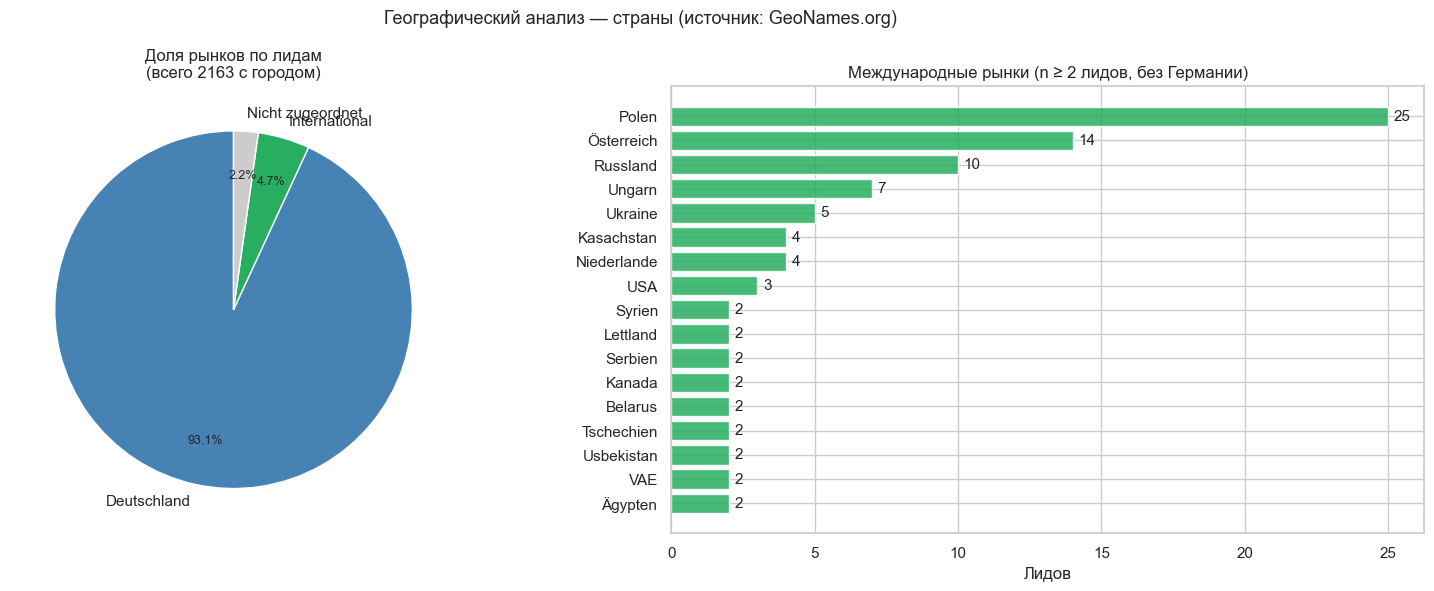

In [56]:
# Левый: доля Deutschland vs международный рынок (пирог)
# Правый: топ международных стран (без DE и Nicht zugeordnet, n >= 2)

de_row   = country_stats[country_stats['Land'] == 'Deutschland']
nz_row   = country_stats[country_stats['Land'] == 'Nicht zugeordnet']
intl     = country_stats[~country_stats['Land'].isin(['Deutschland', 'Nicht zugeordnet'])]

de_leads   = int(de_row['Лидов'].values[0]) if len(de_row) else 0
nz_leads   = int(nz_row['Лидов'].values[0]) if len(nz_row) else 0
intl_leads = int(intl['Лидов'].sum())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый: пирог
labels = ['Deutschland', 'International', 'Nicht zugeordnet']
sizes  = [de_leads, intl_leads, nz_leads]
colors = ['steelblue', '#27ae60', '#cccccc']
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75
)
for t in autotexts:
    t.set_fontsize(9)
axes[0].set_title(f'Доля рынков по лидам\n(всего {de_leads + intl_leads + nz_leads} с городом)')

# Правый: международные страны с n >= 2
intl_top = intl[intl['Лидов'] >= 2].sort_values('Лидов', ascending=True)
bars = axes[1].barh(intl_top['Land'], intl_top['Лидов'], color='#27ae60', alpha=0.85)
axes[1].set_title('Международные рынки (n ≥ 2 лидов, без Германии)')
axes[1].set_xlabel('Лидов')
axes[1].bar_label(bars, fmt='%d', padding=4)

plt.suptitle('Географический анализ — страны (источник: GeoNames.org)', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS + 'geography_countries.png', dpi=100)
plt.show()

**Вывод (раздел 9.2):** Страна определена для **97,8% лидов** с заполненным городом — благодаря открытой базе GeoNames (~200 тыс. населённых пунктов мира). Не определены 48 лидов из мелких населённых пунктов с 1–2 лидами каждый.

Школа работает **преимущественно на немецком рынке: 93,1% лидов (2 014) и 665 050 € выручки** — из Германии. Международный сегмент невелик, но показателен: обнаружено **25+ стран**, включая соседние рынки (Австрия 14 лидов, Польша 25 лидов), русскоязычный контингент (Россия, Казахстан, Украина, Беларусь, Узбекистан — 26 лидов суммарно), а также единичные лиды из Азии, США, Канады, Ближнего Востока.

Международная выручка составляет ~50 000 € (≈7% от выручки по городам), что говорит о реальном, пусть и небольшом, трансграничном спросе на обучение. **Рекомендация:** при масштабировании рассмотреть таргетинг на немецкоязычную Австрию и Польшу как ближайшие смежные рынки с уже существующим спросом.

### 9.3 Уровень немецкого (Level of Deutsch)

ТЗ (п. 3.7.2) предусматривает анализ влияния уровня немецкого на успешность сделок.

Поле `Level of Deutsch` заполнялось менеджерами в свободной форме: кто-то писал `B1`, кто-то — `б1`, `В1`, `в1`, `b1` или `Б1` — всё это одно и то же значение. Кто-то добавлял комментарии («ждёт результата экзамена», «идёт доучивать B1»), кто-то указывал диапазон («B1-B2»). Количество уникальных значений и степень заполнения поля — в коде ниже.

**Подход:** нормализуем всё, что поддаётся приведению к стандарту CEFR. Ненормализуемые записи показываем как примеры проблемного заполнения.

In [57]:
import re

def normalize_level(val):
    """
    Приводит запись к стандарту CEFR (A1/A2/B1/B2/C1/C2) или возвращает None.

    Что нормализуется:
      'б1', 'В1', 'в1', 'Б1', 'b1'  → B1   (кириллица, регистр)
      'B 1', 'B-1', 'B–1'            → B1   (пробел или тире между буквой и цифрой)

    Что НЕ нормализуется (возвращает None):
      'B1-C1', 'в1-в2'               → None (диапазон — единственный уровень неизвестен)
      'идет на B1', 'предположительно B1'
      'ждет результаты экзамена B1'  → None (текст с уровнем внутри — уровень не извлекаем,
                                              т.к. запись несёт дополнительный смысл)
      '?', 'Нет', 'А0', 'f2'        → None (символы вне шкалы CEFR)
    """
    if pd.isna(val):
        return None
    s = str(val).strip()
    # Кириллица → латиница: А→A, В→B (визуально похожа на B), С→C,  Б/б→B (фонетика)
    cyr_map = {'А':'A','а':'A','В':'B','в':'B','Б':'B','б':'B','С':'C','с':'C'}
    for k, v in cyr_map.items():
        s = s.replace(k, v)
    # Убираем разделитель между буквой и цифрой в конце строки: "B-1"→"B1", "B 1"→"B1"
    # Якорь $ гарантирует, что "B1-C1" НЕ изменится — там после 1 ещё идёт "-C1"
    s = re.sub(r'([ABCabc])\s*[-–]\s*([12])$', r'\1\2', s)
    s = re.sub(r'([ABCabc])\s+([12])$',          r'\1\2', s)
    # Строгое соответствие: вся строка должна быть ровно [ABC][12]
    # "B1 " — нет (хвостовой пробел); "B1-C1" — нет; "текст B1" — нет
    m = re.match(r'^([ABCabc])([12])$', s)
    if m:
        return f"{m.group(1).upper()}{m.group(2)}"
    return None  # всё остальное — в категорию «не поддаётся нормализации»

deals['Level_norm'] = deals['Level of Deutsch'].apply(normalize_level)

n_total      = len(deals)
n_filled     = deals['Level of Deutsch'].notna().sum()
n_normalized = deals['Level_norm'].notna().sum()
n_failed     = n_filled - n_normalized

print(f'Всего сделок:              {n_total:,}')
print(f'Заполнено в CRM:           {n_filled:,} ({n_filled / n_total * 100:.1f}%)')
print(f'Нормализовано до CEFR:     {n_normalized:,} ({n_normalized / n_filled * 100:.1f}% от заполненных)')
print(f'Не поддаются нормализации: {n_failed:,} ({n_failed / n_filled * 100:.1f}% от заполненных)')
print()

levels = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
level_counts = (deals['Level_norm']
    .value_counts()
    .reindex(levels)
    .fillna(0)
    .astype(int)
    .rename('Лидов')
    .to_frame())
level_counts['% от норм.'] = (level_counts['Лидов'] / n_normalized * 100).round(1)
print('Распределение нормализованных уровней:')
display(level_counts)

Всего сделок:              21,593
Заполнено в CRM:           1,251 (5.8%)
Нормализовано до CEFR:     989 (79.1% от заполненных)
Не поддаются нормализации: 262 (20.9% от заполненных)

Распределение нормализованных уровней:


,Лидов,% от норм.
Level_norm,,
A1,19,1.9
A2,108,10.9
B1,686,69.4
B2,148,15.0
C1,25,2.5
C2,3,0.3


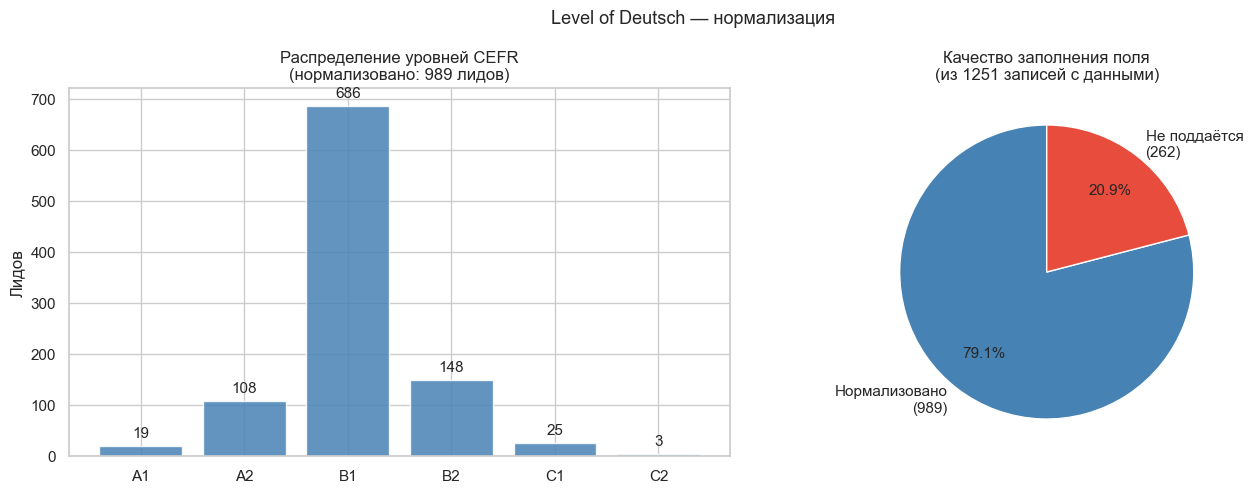

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Левый: распределение CEFR-уровней
levels = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
counts = deals['Level_norm'].value_counts().reindex(levels).fillna(0).astype(int)
bars = axes[0].bar(levels, counts, color='steelblue', alpha=0.85)
axes[0].set_title(f'Распределение уровней CEFR\n(нормализовано: {n_normalized} лидов)')
axes[0].set_ylabel('Лидов')
axes[0].bar_label(bars, fmt='%d', padding=4)

# Правый: нормализовано vs не поддаётся
axes[1].pie(
    [n_normalized, n_failed],
    labels=[f'Нормализовано\n({n_normalized})', f'Не поддаётся\n({n_failed})'],
    colors=['steelblue', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.7,
)
axes[1].set_title(f'Качество заполнения поля\n(из {n_filled} записей с данными)')

plt.suptitle('Level of Deutsch — нормализация', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS + 'level_of_deutsch.png', dpi=100)
plt.show()

In [59]:
# Записи, которые не удалось привести к стандарту CEFR
bad = (deals[deals['Level of Deutsch'].notna() & deals['Level_norm'].isna()]
       .copy()
       .assign(_len=lambda d: d['Level of Deutsch'].str.len()))

print(f'Нестандартных записей всего: {len(bad)}')
print()

print('─' * 60)
print('ПРИМЕР 1 — свободный текст с уровнем внутри (топ-10 длинных)')
print('  Уровень присутствует, но ячейка заполнена как заметка,')
print('  поэтому извлечь одно значение невозможно.')
print('─' * 60)
for v in bad.nlargest(10, '_len')['Level of Deutsch']:
    print(f'  • {v}')

print()
print('─' * 60)
print('ПРИМЕР 2 — диапазоны, символы, опечатки (короткие нестандартные)')
print('  Не соответствуют стандарту CEFR и не могут быть однозначно')
print('  интерпретированы.')
print('─' * 60)
short_bad = (bad[bad['_len'] <= 6]['Level of Deutsch']
             .drop_duplicates()
             .sort_values()
             .reset_index(drop=True))
print(', '.join(repr(v) for v in short_bad))

Нестандартных записей всего: 262

────────────────────────────────────────────────────────────
ПРИМЕР 1 — свободный текст с уровнем внутри (топ-10 длинных)
  Уровень присутствует, но ячейка заполнена как заметка,
  поэтому извлечь одно значение невозможно.
────────────────────────────────────────────────────────────
  • ЯЗ: нем В1 был экз 03.05 повтор и сейчас ждет результаты. Технический англ был. А1 сейчас. ОБР: 2 во информационные и комп сети - инженер системоте
  • Гражданка Германии уже год в Германии Учит немецкий и в сентябре b1 через гос-во проходит, а не через ДЖЦ, вечером учится 3 р в неделю с 18 до 21
  • Нет сертификатов, но есть С1 англ, неоконченное высшее в ИТ (и еще одно высшее юридическое) , очень хочет в ИТ, сильно замотивирована именно н
  • курс А2-В1 - сдача в июле, но вечерняя смена инт курсов, настроен получить гутшайн уже сейчас.
  • Учиться на B1 во вторую смену, в первую хочет получить одобрение на обучение у нас
  • lэкзамен - 6 июля на В1. курсы вечером (но 

**Вывод (раздел 9.3):** Нормализация кириллицы, регистра и пробелов позволила привести **989 из 1 251 записей (79,1%)** к стандарту CEFR. Среди них безусловно доминирует уровень **B1 (686 лидов, 69,4%)** — именно его требует программа Job Center для получения Gutschein. За ним следуют B2 (148) и A2 (108).

Оставшиеся **262 записи (20,9%)** не поддаются нормализации: это свободный текст с комментариями менеджеров («ждёт результаты экзамена», «идёт доучивать B1»), диапазоны (B1-B2, A2-B1), неизвестные символы («?», «Нет», «А0») и прочий мусор.

Однако даже нормализованные 989 записей — лишь **4,6% всех сделок** — слишком мало для надёжного сравнения конверсии по уровням. Анализ по такой выборке дал бы смещённые результаты: поле заполняют избирательно, что нарушает репрезентативность.

**Рекомендация:** перевести поле `Level of Deutsch` на выпадающий список в CRM (A1 / A2 / B1 / B2 / C1 / C2 / kein Deutsch). После 6–12 месяцев сбора стандартизированных данных анализ влияния уровня языка на конверсию станет статистически обоснованным.

## 10. Сводные бизнес-выводы

In [60]:
# Итоговые числа для сводных выводов
peak = monthly_deals.loc[monthly_deals['Deals Count'].idxmax()]
best_conv_month = monthly_conv.loc[monthly_conv['Conversion %'].idxmax()]

best_campaign = (campaign_stats[campaign_stats['Лидов'] >= 30]
                 .nlargest(1, 'Конверсия %').iloc[0])

# Лучший менеджер — по составному рейтингу (раздел 7.6), не по одной конверсии
best_mgr = score_df.nlargest(1, 'Рейтинг (0–100)').iloc[0]

# Ведущий продукт — по выручке (конверсия у трёх основных одинакова ~23%)
best_prod = product_stats[product_stats['Сделок'] >= 100].nlargest(1, 'Выручка').iloc[0]

top_lost = lost_reason.index[0]
top_lost_pct = lost_reason.iloc[0] / total_lost

print('=== Ключевые числа (Этап 3) ===')
print(f'Пик лидов:          {peak["Month"].strftime("%b %Y")} — {peak["Deals Count"]} сделок')
print(f'Лучшая конверсия:   {best_conv_month["Month"].strftime("%b %Y")} — {best_conv_month["Conversion %"]}%')
print(f'Лучшая кампания:    {best_campaign["Campaign"]} ({best_campaign["Конверсия %"]}%)')
print(f'Лучший менеджер:    {score_df["Рейтинг (0–100)"].idxmax()} (рейтинг {best_mgr["Рейтинг (0–100)"]})')
print(f'Ведущий продукт:    {best_prod["Product"]} ({best_prod["Выручка"]:,.0f} € выручка)')
print(f'Гл. причина потери: «{top_lost}» ({top_lost_pct:.1%})')

=== Ключевые числа (Этап 3) ===
Пик лидов:          Apr 2024 — 3082 сделок
Лучшая конверсия:   Dec 2023 — 5.8%
Лучшая кампания:    Trigger_DE (13.16%)
Лучший менеджер:    Oliver Taylor (рейтинг 91.5)
Ведущий продукт:    Digital Marketing (531,900 € выручка)
Гл. причина потери: «Doesn't Answer» (25.9%)


### Итоговые рекомендации

1. **Временные ряды:** Пик по объёму лидов — апрель 2024 (3 082 сделки), но конверсия в этом месяце упала до 2,47%. Лучшая конверсия — декабрь 2023 (5,80%). Масштабирование трафика без контроля качества разрушает воронку.
   → Ввести качественный фильтр при масштабировании кампаний.

2. **Кампании:** 154 кампании, лучшие по конверсии (≥ 30 лидов) — `Trigger_DE` (13,16%), `brand_search_eng_DE` (8,93%).
   → Масштабировать брендовые и ретаргетинговые кампании; снизить бюджет широкого охвата.

3. **Источники:** Самый дорогой канал — Google Ads (57 799 €), но даёт лишь 9,6% качественных лидов. Partnership (16,2%), Facebook Ads (13,0%) и Webinar (12,9%) — лидеры по качеству.
   → Перераспределить бюджет в сторону вебинаров и Webinar-формата.

4. **Менеджеры:** Средняя конверсия — 3,95%, разброс — 6,34%. Лидер — Oliver Taylor (рейтинг 91.5 из 100; конверсия 30,67%) vs 7 менеджеров с рейтингом ниже 20.
   → Провести аудит работы аутсайдеров, внедрить best practices лидера.

5. **Продукты:** Digital Marketing лидирует по выручке — 531 900 € (474 оплаты). Конверсия трёх основных продуктов одинакова (~23%), средний чек 1 000–1 200 €.
   → Конкурентное преимущество — не в продукте, а в маркетинге и продажах.

6. **Потери:** «Doesn't Answer» — 25,9% всех потерь. Связка с SLA из этапа 2 критична.
   → Приоритет — первый контакт в течение 1 часа.

7. **География:** 875 городов. Среди городов с достаточной выборкой (n ≥ 30): лидеры по конверсии — Берлин (42,9%), Лейпциг (40,0%), Мюнхен (36,5%).
   → Усилить гео-таргетинг на крупные немецкие города с высокой конверсией.

---
*Следующий этап: `04_unit_economics.ipynb` — CAC, ARPPU, юнит-экономика по продуктам и каналам.*